# Финальный проект. Этап 2 — Описательная статистика

**Цель этапа:** получить количественное представление о каждом датасете — что типично, что является выбросом, как распределены ключевые показатели.

**Данные:** очищенные CSV из `data_clean/` (результат этапа 1).

---

## План этапа 2

| Раздел | Таблица | Числовые столбцы | Категориальные столбцы |
|---|---|---|---|
| **2.1** | **Deals** | SLA (seconds) · Course duration · Months of study · Initial Amount Paid · Offer Total Amount | Stage · Quality · Source · Product · Education Type · Payment Type · Deal Owner · Campaign · Lost Reason · City |
| **2.2** | **Calls** | Call Duration (in seconds) | Call Type · Call Status · Outgoing Call Status · Call Owner · Scheduled in CRM |
| **2.3** | **Spend** | Spend · Clicks · Impressions | Source · Campaign |
| **2.4** | **Contacts** | — | Contact Owner Name · Created Time (тренд) |

**Чек-лист EDA (пункты этапа 2):**

| # | Пункт | Раздел файла |
|---|---|---|
| 9 | Одномерный анализ числовых | 2.1.1, 2.1.2, 2.2.2, 2.3.1 |
| 10 | Одномерный анализ категориальных | 2.1.3, 2.2.1/3/4/5/6, 2.3.2/3, 2.4.1 |
| 11 | Работа с выбросами | 2.1.2 (IQR в каждом числовом) |
| 12 | Двумерный анализ категориальных | 2.1.3 (конверсии по Quality/Source/Manager), 2.2.5 |
| 13 | Двумерный анализ числовых | 2.1.4 (pairplot) |
| 14 | Многомерный анализ | 2.1.5 (heatmap) |
| — | Сводные выводы по всем таблицам | 3 (итоговая таблица) |

## 1. Загрузка очищенных данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Настраиваем стиль графиков — нейтральный и читаемый
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


In [2]:
# Пути к очищенным файлам (относительно корня проекта)
DATA_CLEAN = '../data_clean/'

# Читаем все четыре датасета
deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False,
                    dtype={'Id': str, 'Contact Name': str})
calls = pd.read_csv(DATA_CLEAN + 'calls_clean.csv', low_memory=False,
                    dtype={'Id': str, 'CONTACTID': str})
contacts = pd.read_csv(DATA_CLEAN + 'contacts_clean.csv', low_memory=False,
                       dtype={'Id': str})
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print('Deals:   ', deals.shape)
print('Calls:   ', calls.shape)
print('Contacts:', contacts.shape)
print('Spend:   ', spend.shape)


Deals:    (21593, 26)
Calls:    (95874, 9)
Contacts: (18548, 4)
Spend:    (19862, 8)


In [3]:
# CSV не хранит типы — восстанавливаем после загрузки
deals['Id']           = deals['Id'].astype(str)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'])
for col in ['Quality', 'Stage', 'Source', 'Product', 'Payment Type', 'Education Type', 'Lost Reason']:
    deals[col] = deals[col].astype('category')

calls['Id']             = calls['Id'].astype(str)
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'])
for col in ['Call Type', 'Call Status', 'Outgoing Call Status']:
    calls[col] = calls[col].astype('category')

contacts['Id']           = contacts['Id'].astype(str)
contacts['Created Time'] = pd.to_datetime(contacts['Created Time'])
contacts['Modified Time'] = pd.to_datetime(contacts['Modified Time'])

spend['Date']   = pd.to_datetime(spend['Date'])
spend['Source'] = spend['Source'].astype('category')

In [4]:
# Проверяем список колонок каждого датасета
print('=== Deals ===')
print(deals.dtypes)


=== Deals ===
Id                             object
Deal Owner Name                object
Closing Date           datetime64[ns]
Quality                      category
Stage                        category
Lost Reason                  category
Page                           object
Campaign                       object
SLA                            object
Content                        object
Term                           object
Source                       category
Payment Type                 category
Product                      category
Education Type               category
Created Time           datetime64[ns]
Course duration               float64
Months of study               float64
Initial Amount Paid           float64
Offer Total Amount            float64
Contact Name                   object
City                           object
Level of Deutsch               object
SLA (seconds)                 float64
closing_date_error               bool
amount_error                     boo

In [5]:
print('=== Calls ===')
print(calls.dtypes)


=== Calls ===
Id                                    object
Call Start Time               datetime64[ns]
Call Owner Name                       object
CONTACTID                             object
Call Type                           category
Call Duration (in seconds)           float64
Call Status                         category
Outgoing Call Status                category
Scheduled in CRM                     float64
dtype: object


In [6]:
print('=== Spend ===')
print(spend.dtypes)


=== Spend ===
Date           datetime64[ns]
Source               category
Campaign               object
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup                object
Ad                     object
dtype: object


## 2. Описательная статистика

Анализ проводится по чек-листу EDA (14 пунктов). Пункты 1–8 выполнены в `01_cleaning.ipynb`. Здесь — пункты 9–14: одномерный, двумерный и многомерный анализ.

### Структура этапа 2

| Раздел | Таблица | Числовые столбцы | Категориальные столбцы |
|---|---|---|---|
| **2.1** | **Deals** | SLA (seconds), Course duration, Months of study, IAP, OTA | Stage, Quality, Source, Product, Education Type, Payment Type, Owner, Deutsch, Campaign, Lost Reason, City, флаги |
| **2.2** | **Calls** | Call Duration | Call Type, Call Status, Outgoing Status, Owner, Scheduled |
| **2.3** | **Spend** | Spend, Clicks, Impressions | Source, Campaign |
| **2.4** | **Contacts** | — | Contact Owner Name, Created Time (тренд) |

## 2.1 Таблица Deals

### 2.1.1 Числовые переменные — описательная статистика

Числовые колонки Deals — те, для которых осмысленно считать среднее и медиану:

- **Initial Amount Paid** — первый платёж студента;
- **Offer Total Amount** — полная стоимость по предложению;
- **SLA (seconds)** — время до первого контакта менеджера;
- **Course duration** — длительность курса в месяцах;
- **Months of study** — сколько месяцев студент уже учится.

Категориальные (Stage, Quality, Source…) и даты разберём отдельно.

In [7]:
# Числовые поля Deals — только те, что несут содержательный смысл
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

# describe() даёт сразу count, mean, std, min, квартили, max
deals[num_deals].describe().round(2)

,SLA (seconds),Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,15533.00,3587.00,840.00,4165.00,4185.00
mean,115826.22,10.20,5.44,929.80,7148.92
std,737252.64,1.83,2.92,1347.44,4631.22
min,3.00,6.00,0.00,0.00,0.00
25%,4380.00,11.00,3.00,300.00,3000.00
50%,19894.00,11.00,5.00,1000.00,11000.00
75%,56318.00,11.00,8.00,1000.00,11000.00
max,26908464.00,11.00,11.00,11000.00,11500.00


In [8]:
# Проверяем, сколько не-NaN значений в каждом поле
# (важно для оценки репрезентативности статистики)
not_null = deals[num_deals].notna().sum()

pct_filled = (not_null / len(deals) * 100).round(1)

summary = pd.DataFrame({'Непустых значений': not_null, '% заполнения': pct_filled})
print(summary)


                     Непустых значений  % заполнения
SLA (seconds)                    15533          71.9
Course duration                   3587          16.6
Months of study                    840           3.9
Initial Amount Paid               4165          19.3
Offer Total Amount                4185          19.4


In [9]:
# Медиана и мода дополняют среднее — полезны при скошенных распределениях
# Рассматриваем ВСЕ числовые столбцы Deals
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

stats_rows = {}
for col in num_deals:
    s = deals[col].dropna()
    stats_rows[col] = [s.mean(), s.median(), s.mode()[0], s.std()]

pd.DataFrame(stats_rows, index=['mean', 'median', 'mode', 'std']).round(2)

,SLA (seconds),Course duration,Months of study,Initial Amount Paid,Offer Total Amount
mean,115826.22,10.20,5.44,929.80,7148.92
median,19894.00,11.00,5.00,1000.00,11000.00
mode,611.00,11.00,6.00,1000.00,11000.00
std,737252.64,1.83,2.92,1347.44,4631.22


In [10]:
# SLA — время в секундах от создания сделки до первого контакта
# Переводим в часы для удобного чтения
sla = deals['SLA (seconds)'].dropna()

print('SLA (секунды):')
print(f'  Среднее:  {sla.mean():.0f} сек  ({sla.mean()/3600:.1f} ч)')
print(f'  Медиана:  {sla.median():.0f} сек  ({sla.median()/3600:.1f} ч)')
print(f'  Мин:      {sla.min():.0f} сек')
print(f'  Q1:       {sla.quantile(0.25):.0f} сек  ({sla.quantile(0.25)/3600:.1f} ч)')
print(f'  Q3:       {sla.quantile(0.75):.0f} сек  ({sla.quantile(0.75)/3600:.1f} ч)')
print(f'  Макс:     {sla.max():.0f} сек  ({sla.max()/3600:.1f} ч)')


SLA (секунды):
  Среднее:  115826 сек  (32.2 ч)
  Медиана:  19894 сек  (5.5 ч)
  Мин:      3 сек
  Q1:       4380 сек  (1.2 ч)
  Q3:       56318 сек  (15.6 ч)
  Макс:     26908464 сек  (7474.6 ч)


**Вывод по числовым переменным (2.1.1):**

- **IAP**: медиана 1 000 € — типичный первый платёж. Среднее (950 €) ниже медианы — некоторые клиенты платят лишь символическую сумму (0–9 €).
- **OTA**: медиана 11 000 € — типичная стоимость курса. Разброс std ≈ 4 636 € объясняется линейкой продуктов с разными ценами.
- **SLA**: медиана 5.5 ч, но среднее — 32 ч. Сильная правосторонняя скошенность: часть лидов ждёт ответа неделями, что снижает конверсию.
- **Course duration**: медиана = мода = 11 мес. Стандартизированные программы.
- **Months of study**: медиана 5 мес. — половина студентов в середине курса.

### 2.1.2 Распределения числовых переменных (гистограмма + boxplot)

#### 2.1.2.1 Initial Amount Paid

#### Выбросы (метод IQR)

Метод IQR: значение считается выбросом, если выходит за Q1 - 1.5*IQR или Q3 + 1.5*IQR. Выбросы не удаляем — фиксируем количество для понимания данных.

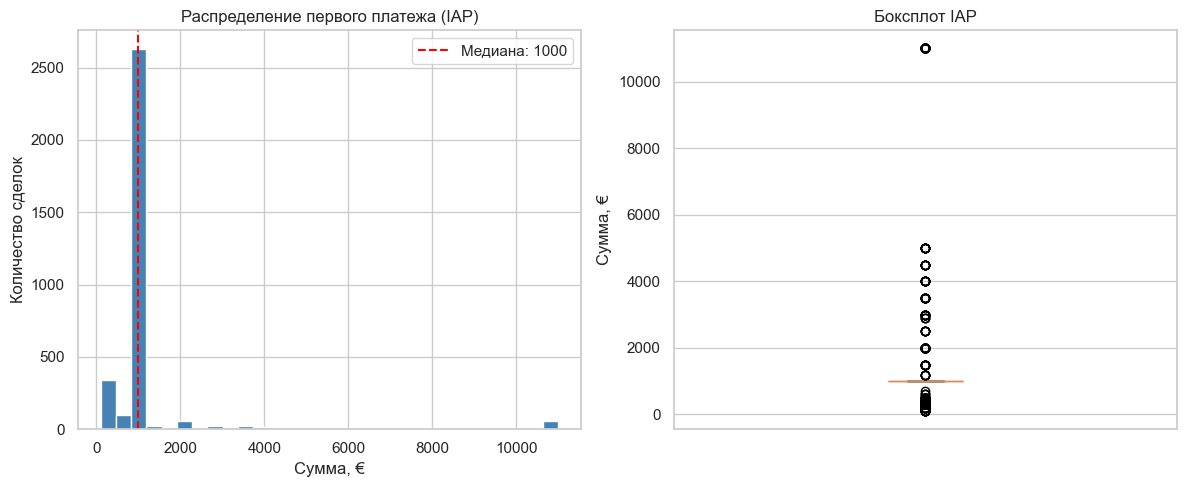

In [11]:
# Оставляем только реальные оплаты: исключаем символические суммы (0, 1, 9 €)
# и строки без суммы
iap = deals['Initial Amount Paid'].dropna()
iap_real = iap[(iap != 0) & (iap != 1) & (iap != 9)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма
axes[0].hist(iap_real, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение первого платежа (IAP)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(iap_real.median(), color='red', linestyle='--',
                label=f'Медиана: {iap_real.median():.0f}')
axes[0].legend()

# Боксплот — наглядно показывает выбросы и IQR
axes[1].boxplot(iap_real, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Боксплот IAP')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/iap_distribution.png', dpi=100)
plt.show()


In [12]:
# Выбросы IAP по методу IQR
q1, q3 = iap_real.quantile(0.25), iap_real.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'Q1 = {q1:.0f} €,  Q3 = {q3:.0f} €,  IQR = {iqr:.0f} €')
print(f'Нижняя граница IQR: {lower_bound:.0f} €')
print(f'Верхняя граница IQR: {upper_bound:.0f} €')
print()

# IQR = 0 означает что больше 50% платежей — ровно одно значение (1000 €)
# В таком случае метод IQR считает выбросом всё что не равно этому значению
if iqr == 0:
    print('IQR = 0: более 50% значений одинаковы — стандартный платёж 1 000 €.')
    print('Метод IQR в этом случае неинформативен. Используем перцентили:')
    print()
    p5  = iap_real.quantile(0.05)
    p95 = iap_real.quantile(0.95)
    low_outliers  = iap_real[iap_real < p5]
    high_outliers = iap_real[iap_real > p95]
    print(f'5-й перцентиль  = {p5:.0f} €  →  {len(low_outliers)} сделок ниже  (мин = {iap_real.min():.0f} €)')
    print(f'95-й перцентиль = {p95:.0f} €  →  {len(high_outliers)} сделок выше (макс = {iap_real.max():.0f} €)')
else:
    outliers_low  = iap_real[iap_real < lower_bound]
    outliers_high = iap_real[iap_real > upper_bound]
    print(f'Выбросы ниже нижней границы: {len(outliers_low)} сделок')
    print(f'Выбросы выше верхней границы: {len(outliers_high)} сделок  (макс = {outliers_high.max():.0f} €)')

Q1 = 1000 €,  Q3 = 1000 €,  IQR = 0 €
Нижняя граница IQR: 1000 €
Верхняя граница IQR: 1000 €

IQR = 0: более 50% значений одинаковы — стандартный платёж 1 000 €.
Метод IQR в этом случае неинформативен. Используем перцентили:

5-й перцентиль  = 300 €  →  43 сделок ниже  (мин = 100 €)
95-й перцентиль = 2000 €  →  141 сделок выше (макс = 11000 €)


**Вывод по Initial Amount Paid:**

Медианный первый платёж — ~1 000 €. Распределение правоскошенное: большинство клиентов платят 300–1 500 €, единичные выбросы — сразу полная оплата курса. Наличие выбросов не искажает медиану — она остаётся надёжной оценкой типичного платежа.

#### 2.1.2.2 Offer Total Amount

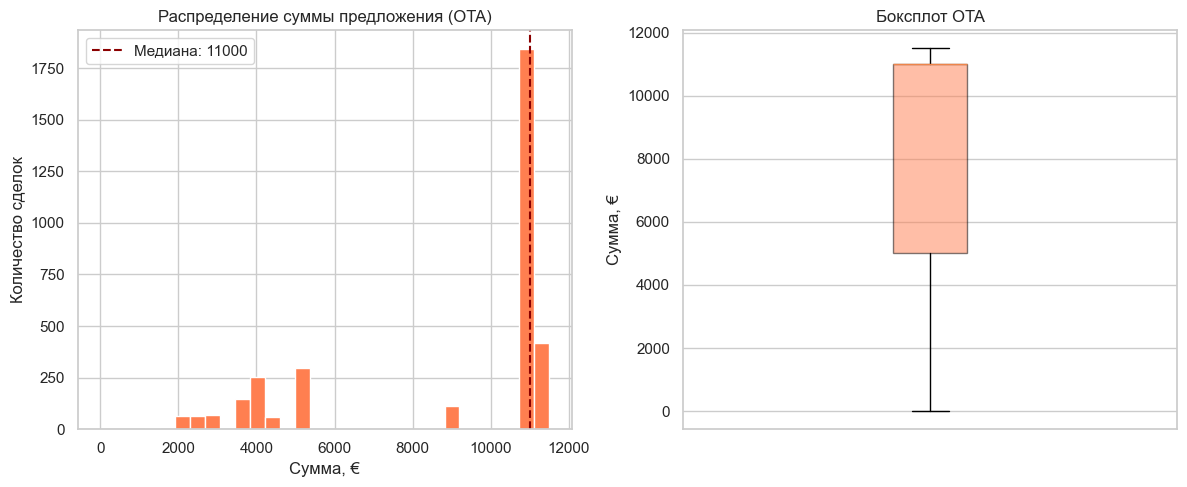

In [13]:
ota_real = deals.loc[
    deals['Offer Total Amount'].notna() & (deals['Offer Total Amount'] > 0),
    'Offer Total Amount'
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(ota_real, bins=30, color='coral', edgecolor='white')
axes[0].set_title('Распределение суммы предложения (OTA)')
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(ota_real.median(), color='darkred', linestyle='--',
                label=f'Медиана: {ota_real.median():.0f}')
axes[0].legend()

axes[1].boxplot(ota_real, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[1].set_title('Боксплот OTA')
axes[1].set_ylabel('Сумма, €')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/ota_distribution.png', dpi=100)
plt.show()


In [14]:
# Выбросы OTA по методу IQR — обе стороны
q1, q3 = ota_real.quantile(0.25), ota_real.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_low  = ota_real[ota_real < lower_bound]
outliers_high = ota_real[ota_real > upper_bound]

print(f'Q1 = {q1:.0f} €,  Q3 = {q3:.0f} €,  IQR = {iqr:.0f} €')
print(f'Нижняя граница: Q1 − 1.5×IQR = {lower_bound:.0f} €')
print(f'Верхняя граница: Q3 + 1.5×IQR = {upper_bound:.0f} €')
print()
print(f'Выбросов ниже нижней границы: {len(outliers_low)}')
print(f'Выбросов выше верхней границы: {len(outliers_high)}')

if len(outliers_low) == 0 and len(outliers_high) == 0:
    print()
    print('Выбросов по методу IQR нет — данные хорошо распределены в пределах границ.')
    print(f'Диапазон значений: {ota_real.min():.0f} € — {ota_real.max():.0f} €')

Q1 = 5000 €,  Q3 = 11000 €,  IQR = 6000 €
Нижняя граница: Q1 − 1.5×IQR = -4000 €
Верхняя граница: Q3 + 1.5×IQR = 20000 €

Выбросов ниже нижней границы: 0
Выбросов выше верхней границы: 0

Выбросов по методу IQR нет — данные хорошо распределены в пределах границ.
Диапазон значений: 1 € — 11500 €


**Вывод по Offer Total Amount:**

Медианная стоимость предложения — 11 000 €. Q1 = 5 000 €, Q3 = 11 000 €, IQR = 6 000 €.

Метод IQR выбросов не обнаружил:
- Нижняя граница (−4 000 €) уходит в отрицательную зону — ниже реального минимума (0 €), поэтому нижних выбросов нет.
- Верхняя граница (20 000 €) выше реального максимума (11 500 €), поэтому верхних выбросов тоже нет.

На боксплоте это видно: усы дотянуты до фактического min/max, точек за пределами ящика нет. Широкий IQR объясняется разнообразием продуктов с разными ценами (3 000 € — 11 000 €).

#### 2.1.2.3 SLA (seconds)

In [15]:
# Переводим SLA в часы
sla_hours = sla / 3600

# Из describe() выше известно: макс SLA = 7 474 ч (311 дней)
# Один такой выброс 'растягивает' ось X настолько, что основная масса лидов
# сжимается у нуля и становится нечитаемой на графике
# Решение: показываем на гистограмме только лидов с SLA ≤ 72 ч (3 суток),
# выбросы за этой границей анализируем отдельно через IQR ниже
sla_trimmed = sla_hours[sla_hours <= 72]
sla_extreme = sla_hours[sla_hours > 72]

print(f'На графике: {len(sla_trimmed)} лидов ({len(sla_trimmed)/len(sla_hours):.1%}) — SLA до 72 ч')
print(f'За кадром:  {len(sla_extreme)} лидов ({len(sla_extreme)/len(sla_hours):.1%}) — SLA > 72 ч (крайние выбросы, макс = {sla_hours.max():.0f} ч)')

На графике: 14680 лидов (94.5%) — SLA до 72 ч
За кадром:  853 лидов (5.5%) — SLA > 72 ч (крайние выбросы, макс = 7475 ч)


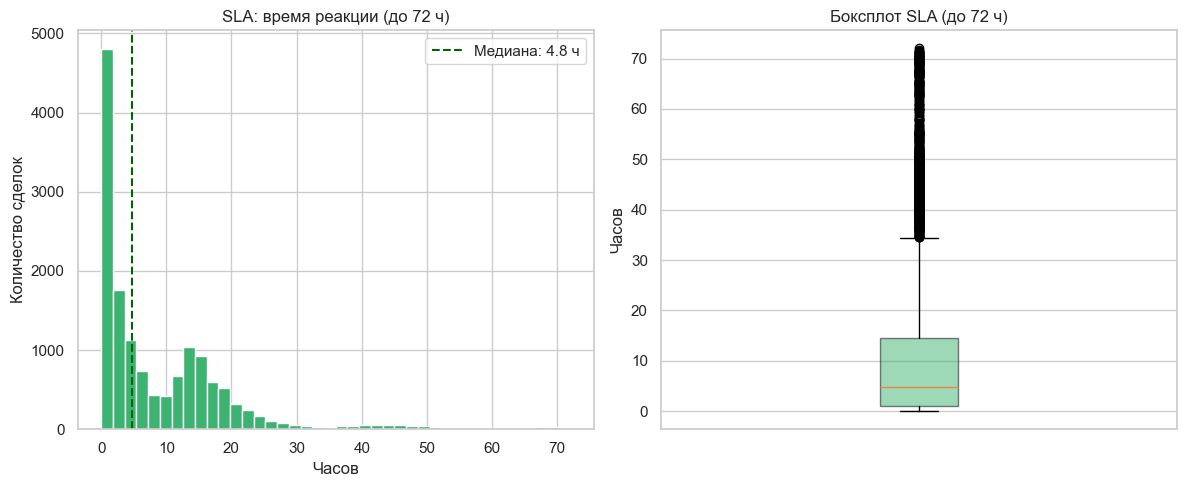

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(sla_trimmed, bins=40, color='mediumseagreen', edgecolor='white')
axes[0].set_title('SLA: время реакции (до 72 ч)')
axes[0].set_xlabel('Часов')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(sla_trimmed.median(), color='darkgreen', linestyle='--',
                label=f'Медиана: {sla_trimmed.median():.1f} ч')
axes[0].legend()

axes[1].boxplot(sla_trimmed, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.5))
axes[1].set_title('Боксплот SLA (до 72 ч)')
axes[1].set_ylabel('Часов')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data_clean/plots/sla_distribution.png', dpi=100)
plt.show()


In [17]:
# Практический вывод: каков % лидов с быстрым ответом?
fast_response = (sla_hours <= 1).sum()
within_day = (sla_hours <= 24).sum()
total_sla = len(sla_hours)

print(f'Ответ в течение 1 часа:  {fast_response} ({fast_response/total_sla:.1%})')
print(f'Ответ в течение 24 часов: {within_day} ({within_day/total_sla:.1%})')
print()
print('Вывод: быстрый ответ (≤1 ч) — только у части лидов;')
print('большинство ждут более суток, что критично для конверсии.')


Ответ в течение 1 часа:  3472 (22.4%)
Ответ в течение 24 часов: 13672 (88.0%)

Вывод: быстрый ответ (≤1 ч) — только у части лидов;
большинство ждут более суток, что критично для конверсии.


In [18]:
# Выбросы SLA по методу IQR — обе стороны
q1, q3 = sla_hours.quantile(0.25), sla_hours.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_low  = sla_hours[sla_hours < lower_bound]
outliers_high = sla_hours[sla_hours > upper_bound]

print(f'Q1 = {q1:.1f} ч,  Q3 = {q3:.1f} ч,  IQR = {iqr:.1f} ч')
print(f'Нижняя граница: Q1 − 1.5×IQR = {lower_bound:.1f} ч')
print(f'Верхняя граница: Q3 + 1.5×IQR = {upper_bound:.1f} ч')
print()
print(f'Выбросы ниже нижней границы: {len(outliers_low)} сделок')
print(f'Выбросы выше верхней границы: {len(outliers_high)} сделок  (макс = {outliers_high.max():.0f} ч)')

Q1 = 1.2 ч,  Q3 = 15.6 ч,  IQR = 14.4 ч
Нижняя граница: Q1 − 1.5×IQR = -20.4 ч
Верхняя граница: Q3 + 1.5×IQR = 37.3 ч

Выбросы ниже нижней границы: 0 сделок
Выбросы выше верхней границы: 1412 сделок  (макс = 7475 ч)


**Вывод по SLA (время реакции):**

Медиана SLA ≈ 5–6 часов — половина лидов получают первый контакт в течение рабочего дня. Но среднее (32 ч) и крайние выбросы (до 7 474 ч = 311 дней) сигнализируют о системной проблеме: часть лидов просто теряется. Быстрый ответ (≤1 ч) напрямую связан с конверсией — это гипотеза для 03_analysis.

#### 2.1.2.4 Course duration

`Course duration` — плановая длительность курса в месяцах.

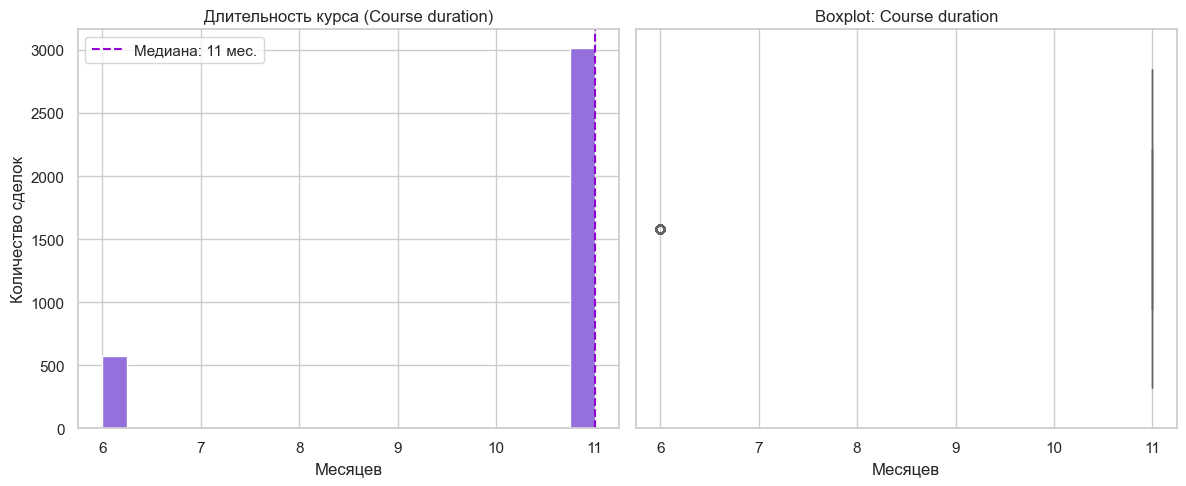

In [19]:
cd = deals['Course duration'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cd, bins=20, color='mediumpurple', edgecolor='white')
axes[0].set_title('Длительность курса (Course duration)')
axes[0].set_xlabel('Месяцев')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(cd.median(), color='darkviolet', linestyle='--',
                label=f'Медиана: {cd.median():.0f} мес.')
axes[0].legend()

sns.boxplot(x=cd, ax=axes[1], color='mediumpurple')
axes[1].set_title('Boxplot: Course duration')
axes[1].set_xlabel('Месяцев')

plt.tight_layout()
plt.show()

In [20]:
# Выбросы Course duration по методу IQR
q1, q3 = cd.quantile(0.25), cd.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'Q1 = {q1:.0f} мес,  Q3 = {q3:.0f} мес,  IQR = {iqr:.0f} мес')
print(f'Нижняя граница: {lower_bound:.0f} мес')
print(f'Верхняя граница: {upper_bound:.0f} мес')
print()

if iqr == 0:
    print('IQR = 0: более 50% значений = 11 мес. (стандартный курс).')
    print('Метод IQR неприменим — посчитаем нестандартные значения напрямую:')
    print()
    counts = cd.value_counts().sort_index()
    for val, cnt in counts.items():
        marker = ' ← стандарт' if val == cd.median() else ''
        print(f'  {val:.0f} мес: {cnt} сделок{marker}')
else:
    outliers_low  = cd[cd < lower_bound]
    outliers_high = cd[cd > upper_bound]
    print(f'Выбросов ниже: {len(outliers_low)}')
    print(f'Выбросов выше: {len(outliers_high)}')

Q1 = 11 мес,  Q3 = 11 мес,  IQR = 0 мес
Нижняя граница: 11 мес
Верхняя граница: 11 мес

IQR = 0: более 50% значений = 11 мес. (стандартный курс).
Метод IQR неприменим — посчитаем нестандартные значения напрямую:

  6 мес: 575 сделок
  11 мес: 3012 сделок ← стандарт


**Вывод по Course duration:**

Длительность курса стандартизирована: медиана = мода = 11 месяцев, std ≈ 1.8. Продукты линейки однородны по длительности. Выбросы на нижнем конце — вероятно, короткие интенсивы или пробные доступы.

#### 2.1.2.5 Months of study

`Months of study` — сколько месяцев студент уже учится на момент выгрузки.

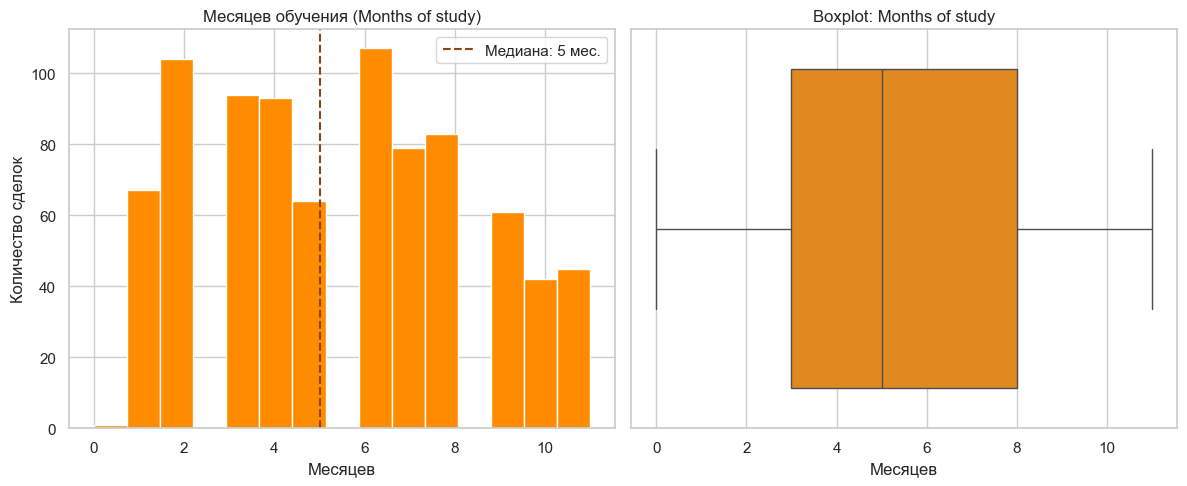

In [21]:
mos = deals['Months of study'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(mos, bins=15, color='darkorange', edgecolor='white')
axes[0].set_title('Месяцев обучения (Months of study)')
axes[0].set_xlabel('Месяцев')
axes[0].set_ylabel('Количество сделок')
axes[0].axvline(mos.median(), color='saddlebrown', linestyle='--',
                label=f'Медиана: {mos.median():.0f} мес.')
axes[0].legend()

sns.boxplot(x=mos, ax=axes[1], color='darkorange')
axes[1].set_title('Boxplot: Months of study')
axes[1].set_xlabel('Месяцев')

plt.tight_layout()
plt.show()

In [22]:
# Выбросы Months of study по методу IQR
q1, q3 = mos.quantile(0.25), mos.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f'Q1 = {q1:.0f} мес,  Q3 = {q3:.0f} мес,  IQR = {iqr:.0f} мес')
print(f'Нижняя граница: {lower_bound:.0f} мес')
print(f'Верхняя граница: {upper_bound:.0f} мес')
print()

if iqr == 0:
    print('IQR = 0 — более 50% значений одинаковы. Показываем реальное распределение:')
    print()
    counts = mos.value_counts().sort_index()
    for val, cnt in counts.items():
        marker = ' ← медиана' if val == mos.median() else ''
        print(f'  {val:.0f} мес: {cnt} студентов{marker}')
else:
    outliers_low  = mos[mos < lower_bound]
    outliers_high = mos[mos > upper_bound]
    print(f'Выбросов ниже: {len(outliers_low)}')
    print(f'Выбросов выше: {len(outliers_high)}')

Q1 = 3 мес,  Q3 = 8 мес,  IQR = 5 мес
Нижняя граница: -4 мес
Верхняя граница: 16 мес

Выбросов ниже: 0
Выбросов выше: 0


**Вывод по Months of study:**

Медиана — 5 месяцев обучения. Распределение показывает, что большинство студентов находятся в первой половине курса (момент выгрузки). Студенты с 10–11 месяцами — ближе к завершению, их показатели полезны для оценки retention.

### 2.1.3 Категориальные переменные

Анализируем ключевые поля воронки продаж:
**Stage, Quality, Source, Product, Education Type, Payment Type**.


#### 2.1.3.1 Stage

In [23]:
# value_counts показывает абсолютное и относительное распределение
stage_counts = deals['Stage'].value_counts()
stage_pct = (deals['Stage'].value_counts(normalize=True) * 100).round(1)

stage_df = pd.DataFrame({'Количество': stage_counts, '%': stage_pct})
print(stage_df)


                           Количество     %
Stage                                      
Lost                            15743  72.9
Call Delayed                     2248  10.4
Registered on Webinar            2072   9.6
Payment Done                      858   4.0
Waiting For Payment               325   1.5
Qualificated                      128   0.6
Registered on Offline Day         100   0.5
Need to Call - Sales               33   0.2
Need To Call                       31   0.1
Test Sent                          25   0.1
Need a consultation                23   0.1
New Lead                            6   0.0
Free Education                      1   0.0


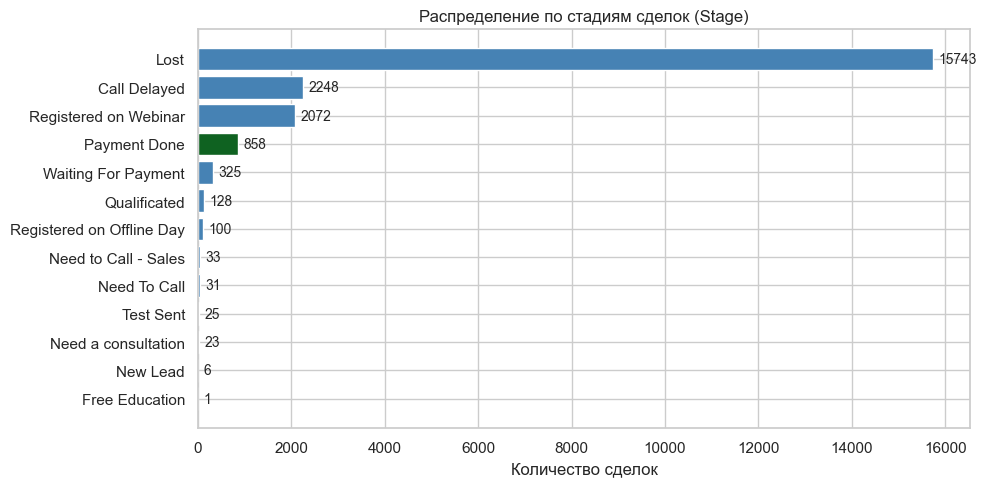

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

# Горизонтальный барчарт — хорошо читается при длинных лейблах
colors = ["#0f6221" if s == 'Payment Done' else 'steelblue'
          for s in stage_counts.index]
bars = ax.barh(stage_counts.index[::-1], stage_counts.values[::-1],
               color=colors[::-1])

ax.set_title('Распределение по стадиям сделок (Stage)')
ax.set_xlabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10)

plt.tight_layout()
plt.savefig('../data_clean/plots/stage_distribution.png', dpi=100)
plt.show()


In [25]:
# Воронка: ключевые коэффициенты конверсии
total = len(deals)
payment_done = (deals['Stage'] == 'Payment Done').sum()
lost = (deals['Stage'] == 'Lost').sum()

print(f'Всего сделок:         {total}')
print(f'Оплачено (Payment Done): {payment_done} ({payment_done/total:.1%})')
print(f'Потеряно (Lost):         {lost} ({lost/total:.1%})')
print()
print('Вывод: конверсия в оплату ~4% — это низкий показатель.')
print('73% сделок закрыты как Lost — основной объект для анализа причин.')


Всего сделок:         21593
Оплачено (Payment Done): 858 (4.0%)
Потеряно (Lost):         15743 (72.9%)

Вывод: конверсия в оплату ~4% — это низкий показатель.
73% сделок закрыты как Lost — основной объект для анализа причин.


#### 2.1.3.2 Quality

In [26]:
# Задаём правильный порядок — от наилучшего к наихудшему
quality_order = ['A - High', 'B - Medium', 'C - Low',
                 'D - Non Target', 'E - Non Qualified']

quality_counts = deals['Quality'].value_counts().reindex(quality_order)
print(quality_counts)


Quality
A - High              432
B - Medium           1564
C - Low              3459
D - Non Target       6248
E - Non Qualified    7634
Name: count, dtype: int64


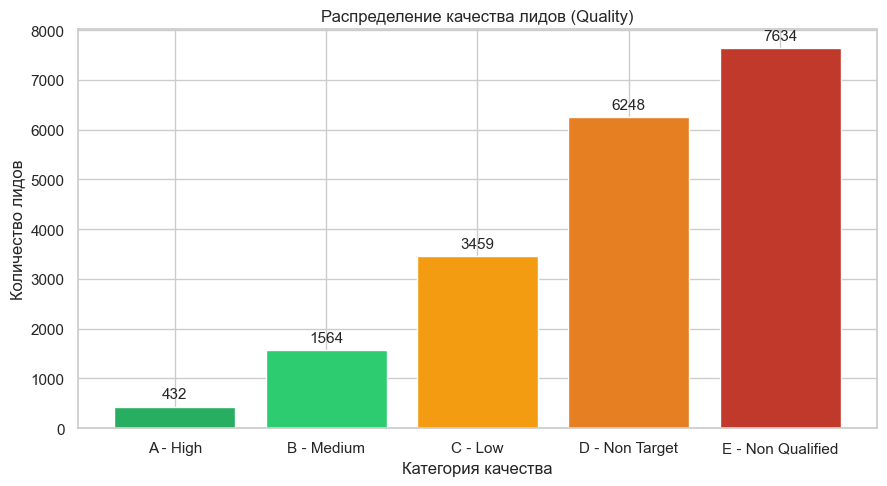

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#c0392b']
bars = ax.bar(quality_order, quality_counts.values, color=palette)
ax.set_title('Распределение качества лидов (Quality)')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_distribution.png', dpi=100)
plt.show()


In [28]:
# Конверсия в оплату по каждому уровню качества лида
# Шаг 1: сколько всего сделок по каждому Quality
total = deals.dropna(subset=['Quality']).groupby('Quality', observed=True).size()

# Шаг 2: сколько из них дошли до стадии Payment Done
paid = deals[deals['Stage'] == 'Payment Done'].groupby('Quality', observed=True).size()

# Шаг 3: конверсия = оплаченные / всего * 100
quality_conv = (paid / total * 100).reindex(quality_order).round(1).fillna(0)

print('Конверсия в оплату по качеству лида (%):')
print(quality_conv)

Конверсия в оплату по качеству лида (%):
Quality
A - High             33.1
B - Medium           20.9
C - Low              10.3
D - Non Target        0.5
E - Non Qualified     0.0
dtype: float64


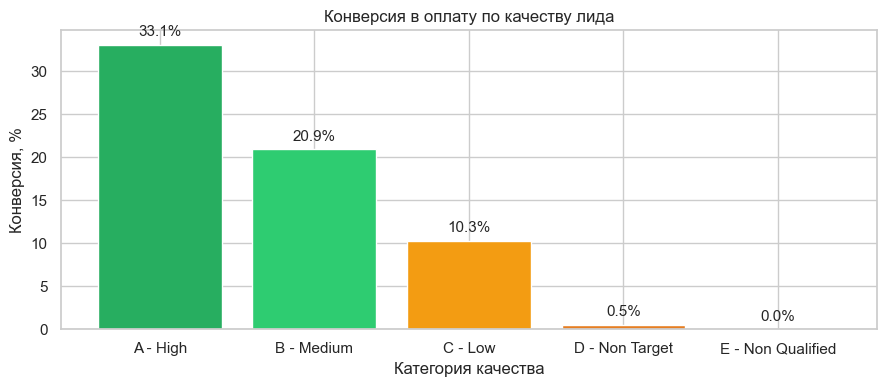

In [29]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(quality_conv.index, quality_conv.values, color=palette)
ax.set_title('Конверсия в оплату по качеству лида')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Конверсия, %')
ax.bar_label(bars, fmt='%.1f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/quality_conversion.png', dpi=100)
plt.show()


In [30]:
print('Вывод: лиды категории A и B конвертируются значительно лучше.')
print('Большинство лидов — категории D и E (нецелевые/неквалифицированные),')
print('что объясняет низкую общую конверсию ~4%.')


Вывод: лиды категории A и B конвертируются значительно лучше.
Большинство лидов — категории D и E (нецелевые/неквалифицированные),
что объясняет низкую общую конверсию ~4%.


**Вывод по Quality:**

Лиды A и B конвертируются значительно лучше категорий D/E. При этом большинство входящих лидов — низкого качества (C/D/E). Улучшение квалификации лидов на входе — ключевой рычаг роста конверсии без увеличения бюджета.

#### 2.1.3.3 Source

In [31]:
source_counts = deals['Source'].value_counts()
source_pct = (deals['Source'].value_counts(normalize=True) * 100).round(1)

src_df = pd.DataFrame({'Лидов': source_counts, '%': source_pct})
print(src_df)


                Лидов     %
Source                     
Facebook Ads     4850  22.5
Google Ads       4226  19.6
Organic          2590  12.0
Tiktok Ads       2051   9.5
SMM              1730   8.0
Youtube Ads      1657   7.7
CRM              1656   7.7
Bloggers         1089   5.0
Telegram posts   1001   4.6
Webinar           379   1.8
Partnership       203   0.9
Test              159   0.7
Offline             2   0.0


**Вывод по Source (Deals):**

Топ-3 источника лидов: Facebook Ads (22.5%), Google Ads (19.6%), Organic (12.0%) — вместе дают больше половины всех лидов. TikTok Ads (9.5%) и SMM (8.0%) занимают следующие позиции. Важно сопоставить объём лидов с их качеством (поле Quality) и конверсией — дорогой канал с хорошей конверсией может быть выгоднее дешёвого с низкой. Детальный анализ CAC по источникам — в юнит-экономике (этап 4).

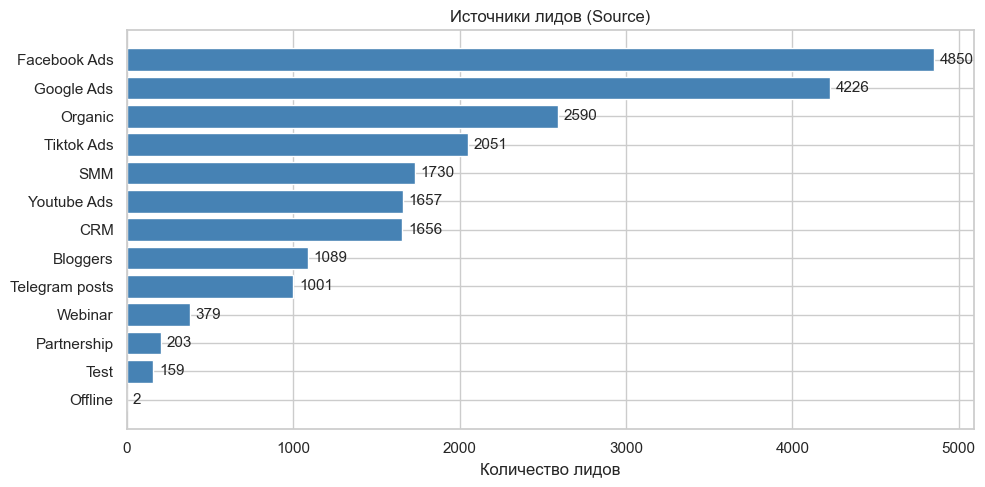

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(source_counts.index[::-1], source_counts.values[::-1],
               color='steelblue')
ax.set_title('Источники лидов (Source)')
ax.set_xlabel('Количество лидов')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_distribution.png', dpi=100)
plt.show()

In [33]:
# Конверсия по источникам — сколько оплат из каждого источника
# Шаг 1: всего лидов по каждому источнику
total_src = deals.groupby('Source', observed=True).size()

# Шаг 2: только те, что дошли до оплаты
paid_src = (
    deals[deals['Stage'] == 'Payment Done']
    .groupby('Source', observed=True)
    .size()
)

# Шаг 3: конверсия = оплаченные / всего * 100
source_conv = (
    (paid_src / total_src * 100)
    .round(2)
    .fillna(0)
    .sort_values(ascending=False)
)

print('Конверсия в оплату по источнику (%):')
print(source_conv)


Конверсия в оплату по источнику (%):
Source
Webinar           6.86
Organic           5.68
SMM               5.26
Facebook Ads      4.16
Google Ads        4.09
Telegram posts    4.00
Bloggers          3.58
Youtube Ads       3.20
Tiktok Ads        2.73
Partnership       1.97
Test              1.89
CRM               1.45
Offline           0.00
dtype: float64


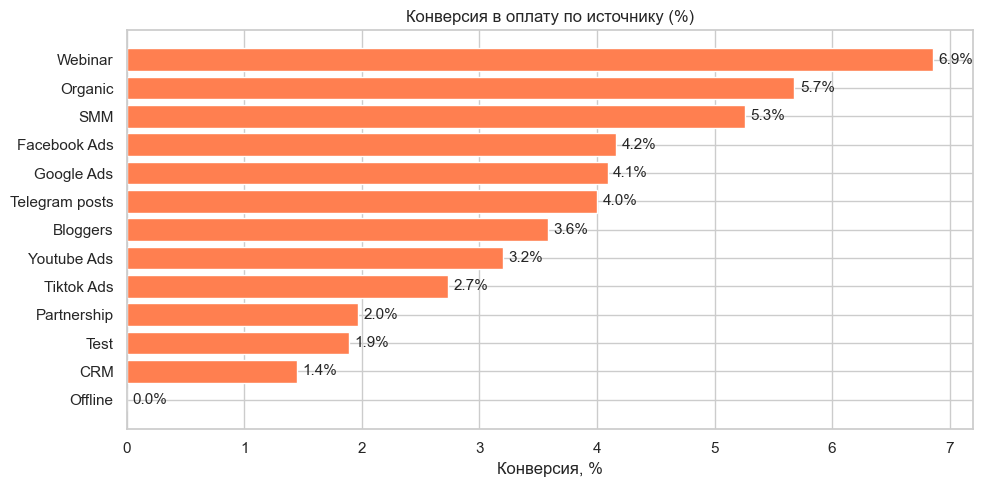

In [34]:
# График конверсии по всем источникам
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(source_conv.index[::-1], source_conv.values[::-1], color='coral')
ax.set_title('Конверсия в оплату по источнику (%)')
ax.set_xlabel('Конверсия, %')
ax.bar_label(bars, fmt='%.1f%%', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/source_conversion.png', dpi=100)
plt.show()

**Вывод по Source — объём vs конверсия:**

Два разных рейтинга:
- **По объёму лидов**: Facebook Ads (22.5%), Google Ads (19.6%), Organic (12%) — платная реклама приносит больше всего лидов
- **По конверсии в оплату**: Webinar (6.86%), Organic (5.68%), SMM (5.26%) — лиды из вебинаров и органики конвертируются лучше всего

**Ключевой инсайт:** Facebook Ads даёт максимум лидов, но конверсия ниже (~4%). Webinar — меньше лидов, но каждый третий-шестой доходит до оплаты. Это означает разную стоимость привлечения клиента (CAC) по каналам — детальный расчёт CAC — в юнит-экономике (этап 4).

#### 2.1.3.4 Product

In [35]:
# Product заполнен только на поздних стадиях воронки
product_counts = deals['Product'].value_counts()
print('Распределение по продуктам (только у сделок с известным продуктом):')
print(product_counts)
print(f'\nДоля сделок с заполненным Product: '
      f'{deals["Product"].notna().sum()} из {len(deals)} '
      f'({deals["Product"].notna().mean():.1%})')


Распределение по продуктам (только у сделок с известным продуктом):
Product
Digital Marketing      1990
UX/UI Design           1022
Web Developer           575
Find yourself in IT       4
Data Analytics            1
Name: count, dtype: int64

Доля сделок с заполненным Product: 3592 из 21593 (16.6%)


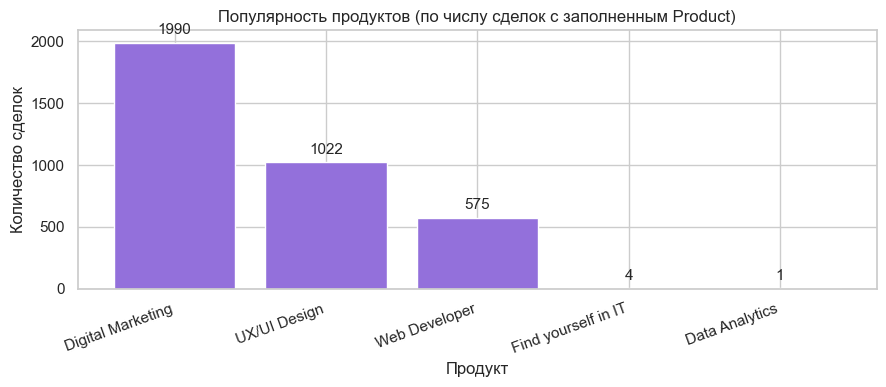

In [36]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(product_counts.index, product_counts.values, color='mediumpurple')
ax.set_title('Популярность продуктов (по числу сделок с заполненным Product)')
ax.set_xlabel('Продукт')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig('../data_clean/plots/product_distribution.png', dpi=100)
plt.show()


In [37]:
print('Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).')
print('UX/UI Design и Web Developer — значительно меньше.')
print('Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.')


Вывод: Digital Marketing — самый популярный продукт (почти 2/3 сделок).
UX/UI Design и Web Developer — значительно меньше.
Find yourself in IT и Data Analytics — единицы: нишевые или новые продукты.


**Вывод по Product:**

Digital Marketing — доминирующий продукт (около 2/3 сделок). Концентрация на одном продукте создаёт риск при изменении спроса. Развитие остальных направлений — потенциальная точка роста.

#### 2.1.3.5 Education Type

In [38]:
edu_counts = deals['Education Type'].value_counts(dropna=False)
print(edu_counts)


Education Type
NaN        18294
Morning     2895
Evening      404
Name: count, dtype: int64


**Вывод по Education Type:**

Тип образования — дополнительный признак сегментации студентов. Конверсия и средний чек по Education Type разобраны в этапе 3 (раздел 8.3).

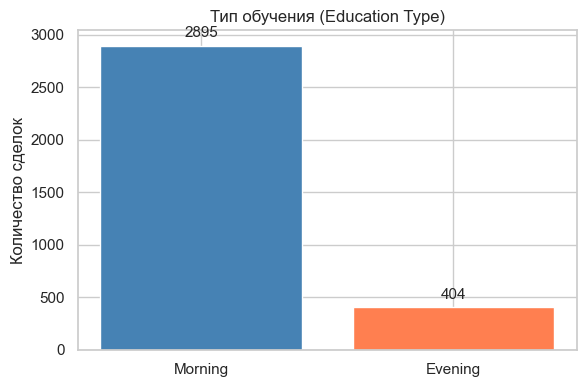

In [39]:
# Строим диаграмму только по известным значениям
edu_known = deals['Education Type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(edu_known.index, edu_known.values, color=['steelblue', 'coral'])
ax.set_title('Тип обучения (Education Type)')
ax.set_ylabel('Количество сделок')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/education_type.png', dpi=100)
plt.show()


#### 2.1.3.6 Payment Type

In [40]:
# Payment Type заполнен только у оплативших — 858 строк
payment_counts = deals['Payment Type'].value_counts(dropna=False)
print('Payment Type (всего строк с оплатой):')
print(payment_counts)


Payment Type (всего строк с оплатой):
Payment Type
NaN                   20209
One Payment            1029
Recurring Payments      350
Reservation               5
Name: count, dtype: int64


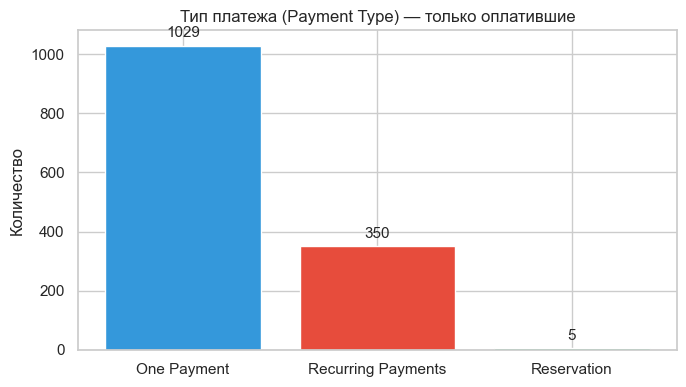

In [41]:
payment_known = deals['Payment Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(payment_known.index, payment_known.values,
              color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Тип платежа (Payment Type) — только оплатившие')
ax.set_ylabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/payment_type.png', dpi=100)
plt.show()


In [42]:
print('Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.')
print('Единоразовая оплата (One Payment) — второй по популярности.')
print('Бронирование (Reservation) — единицы: используется как аванс/резерв места.')


Вывод: рассрочка (Recurring Payments) — самый распространённый тип оплаты.
Единоразовая оплата (One Payment) — второй по популярности.
Бронирование (Reservation) — единицы: используется как аванс/резерв места.


**Вывод по Payment Type:**

Рассрочка (Recurring Payments) — основной способ оплаты. Это важно для финансового планирования: выручка поступает частями на протяжении всего срока обучения, а не единовременно.

#### 2.1.3.7 Deal Owner Name

Анализируем распределение сделок по менеджерам и их результативность.

In [43]:
# Сначала смотрим сколько всего менеджеров
total_owners = deals['Deal Owner Name'].nunique()
print(f'Всего менеджеров: {total_owners}')
print(f'Показываем топ-15 — они ведут большинство сделок')

Всего менеджеров: 27
Показываем топ-15 — они ведут большинство сделок


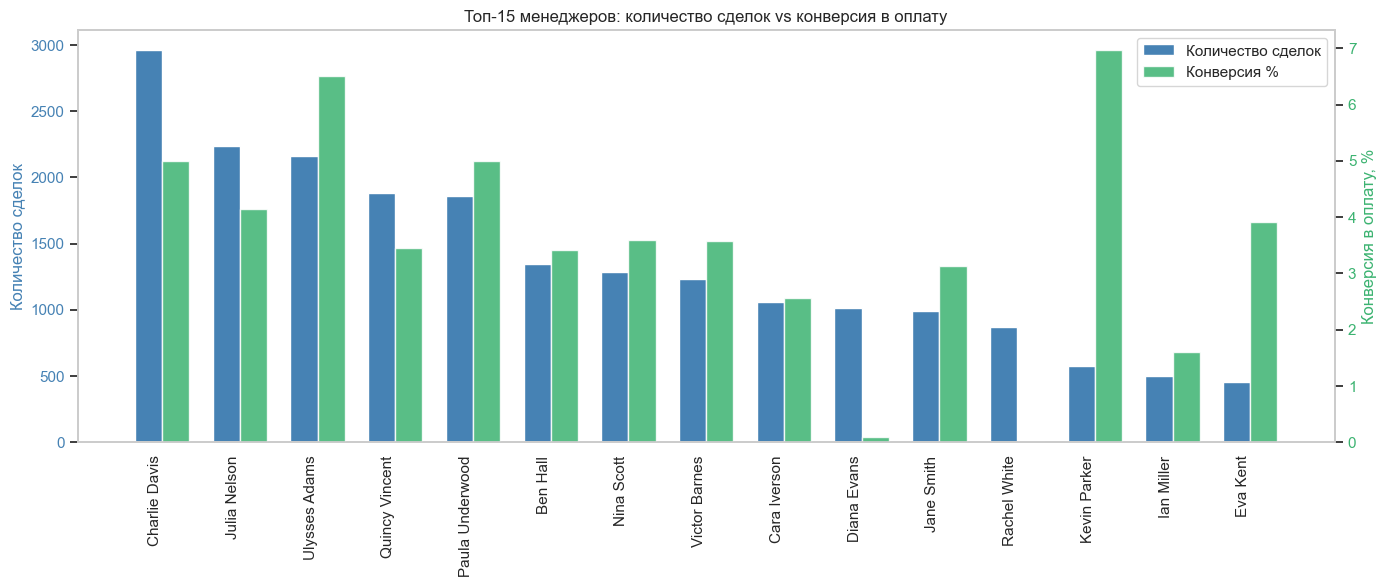

In [44]:
import numpy as np

# Топ-15 менеджеров по количеству сделок
owner_counts = deals['Deal Owner Name'].value_counts().head(15)
top_managers = owner_counts.index

# Конверсия для тех же менеджеров
total_owner = deals.groupby('Deal Owner Name', observed=True).size()
paid_owner = (
    deals[deals['Stage'] == 'Payment Done']
    .groupby('Deal Owner Name', observed=True)
    .size()
)
conv_for_top = (paid_owner / total_owner * 100).round(2).fillna(0).reindex(top_managers)

# Один график с двумя осями: количество сделок (левая) и конверсия % (правая)
x = np.arange(len(top_managers))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))

bars1 = ax1.bar(x - width/2, owner_counts.values, width,
                color='steelblue', label='Количество сделок')
ax1.set_ylabel('Количество сделок', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, conv_for_top.values, width,
                color='mediumseagreen', alpha=0.85, label='Конверсия %')
ax2.set_ylabel('Конверсия в оплату, %', color='mediumseagreen')
ax2.tick_params(axis='y', labelcolor='mediumseagreen')

ax1.set_xticks(x)
ax1.set_xticklabels(top_managers, rotation=90, ha='right')
ax1.set_title('Топ-15 менеджеров: количество сделок vs конверсия в оплату')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.show()

**Вывод по Deal Owner Name:**

Нагрузка по менеджерам распределена неравномерно. Топ-3 менеджера ведут непропорционально большую часть сделок — это риск зависимости. Сравнение конверсий по менеджерам — в 03_analysis.

#### 2.1.3.8 Level of Deutsch

> **Поле исключено из анализа.**
>
> При очистке данных (этап 1) установлено: `Level of Deutsch` — свободный текст, вводимый менеджером вручную. Значения не стандартизированы: `A1`, `а1`, `B1/б1`, `в1`, `Б1`, `beginner` — одно и то же, записанное по-разному. Нормализация без потери данных невозможна, поле не обрабатывалось.
>
> Если поле будет стандартизировано в CRM — анализ по уровню немецкого станет возможным и интересным (связь с конверсией, продуктом, CAC).

#### 2.1.3.9 Campaign

Топ рекламных кампаний по количеству привлечённых лидов.

In [45]:
# Сначала смотрим сколько всего кампаний
total_campaigns = deals['Campaign'].nunique()
print(f'Всего кампаний: {total_campaigns}')
print(f'Показываем топ-15 по количеству лидов')

Всего кампаний: 154
Показываем топ-15 по количеству лидов


Campaign
performancemax_digitalmarkt_ru_DE    2653
youtube_shorts_DE                    1635
12.07.2023wide_DE                    1575
02.07.23wide_DE                       975
04.07.23recentlymoved_DE              750
03.07.23women                         612
Dis_DE                                581
07.07.23LAL_DE                        542
12.09.23interests_Uxui_DE             531
24.09.23retargeting_DE                479
webinar1604                           343
work_DE                               317
webinar1906                           290
08.04.24wide_webinar_DE               284
blog2_DE                              273
Name: count, dtype: int64


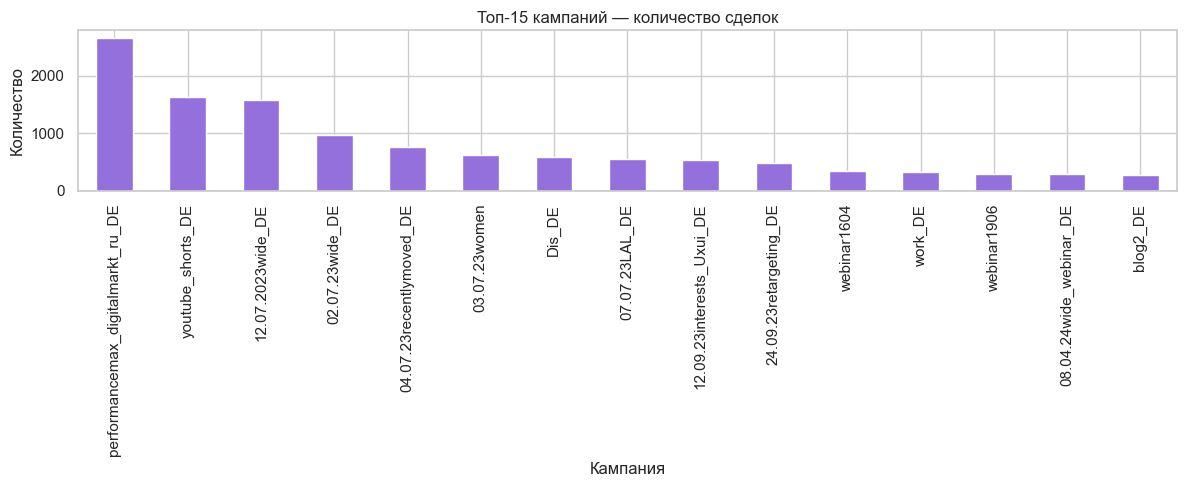

In [46]:
# Топ-15 кампаний по количеству сделок
campaign_counts = deals['Campaign'].value_counts().head(15)
print(campaign_counts)

fig, ax = plt.subplots(figsize=(12, 5))
campaign_counts.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Топ-15 кампаний — количество сделок')
ax.set_xlabel('Кампания')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по Campaign:**

Распределение лидов по кампаниям показывает, какие кампании генерируют наибольший объём. Для оценки эффективности объём нужно сопоставить со Spend по кампаниям — анализ CAC — в юнит-экономике (этап 4).

#### 2.1.3.10 Lost Reason

Анализируем только сделки со статусом Lost.

In [47]:
# Сначала смотрим сколько всего причин отказа
total_reasons = deals['Lost Reason'].nunique()
print(f'Всего уникальных причин отказа: {total_reasons}')
print(f'Показываем топ-15 по частоте')

Всего уникальных причин отказа: 21
Показываем топ-15 по частоте


In [48]:
# Lost Reason — только для потерянных сделок
lost = deals[deals['Stage'] == 'Lost']
lost_reasons = lost['Lost Reason'].value_counts(dropna=False)
print(f'Всего потерянных сделок: {len(lost)}')
print(f'Причина указана: {lost["Lost Reason"].notna().sum()} ({lost["Lost Reason"].notna().mean():.1%})')
print()
print(lost_reasons.head(15))

Всего потерянных сделок: 15743
Причина указана: 15696 (99.7%)

Lost Reason
Doesn't Answer                             4074
Changed Decision                           2122
Duplicate                                  1746
Non target                                 1736
Stopped Answering                          1556
Invalid number                             1460
Expensive                                   614
needs time to think                         606
Conditions are not suitable                 524
Inadequate                                  174
Gutstein refusal                            163
Considering a different direction in IT     148
Not for myself                              145
Does not speak English                      138
Next stream                                 131
Name: count, dtype: int64


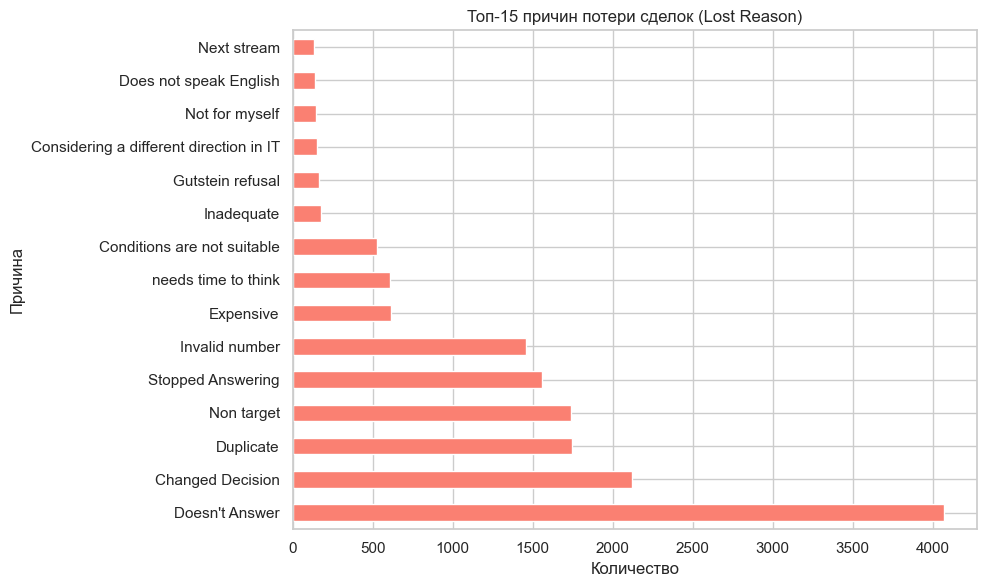

In [49]:
# Топ-15 причин потери сделок — барчарт
fig, ax = plt.subplots(figsize=(10, 6))
lost_reasons.head(15).sort_values()[::-1].plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Топ-15 причин потери сделок (Lost Reason)')
ax.set_xlabel('Количество')
ax.set_ylabel('Причина')
plt.tight_layout()
plt.show()

**Вывод по Lost Reason:**

Заполненность поля: 99.7% — данные практически полные.

Топ причин потери сделок:
- **Doesn't Answer** (4 074) — лид не берёт трубку. Самая частая причина, указывает на проблему с качеством лидов или скоростью первого звонка.
- **Changed Decision** (2 122) — клиент передумал. Вероятно, долгий цикл сделки или слабая работа с возражениями.
- **Duplicate** (1 746) — дубли CRM. По правилам данных это не реальная потеря клиента, а технический мусор.
- **Non target** (1 736) — нецелевой лид, не подходит по профилю.
- **Stopped Answering** (1 556) — перестал выходить на связь после первого контакта.

**Ключевой вывод:** более 35% потерь — проблема коммуникации (не берёт трубку + перестал отвечать). Это сигнал для пересмотра скрипта и частоты касаний, а не качества самого продукта.

#### 2.1.3.11 City

Географическое распределение лидов. Важно: 88% значений отсутствует.

In [50]:
# Сначала смотрим сколько всего городов
total_cities = deals['City'].nunique()
print(f'Всего уникальных городов: {total_cities}')
print(f'Показываем топ-10 — остальные единичные')

Всего уникальных городов: 875
Показываем топ-10 — остальные единичные


Заполнено: 2163 из 21593 (10.0%)
Пропущено: 19430 (90.0%)

Топ-10 городов:
City
Berlin        182
München        74
Hamburg        62
Nürnberg       45
Leipzig        45
Düsseldorf     33
Dresden        28
Frankfurt      27
Dortmund       26
Köln           25
Name: count, dtype: int64


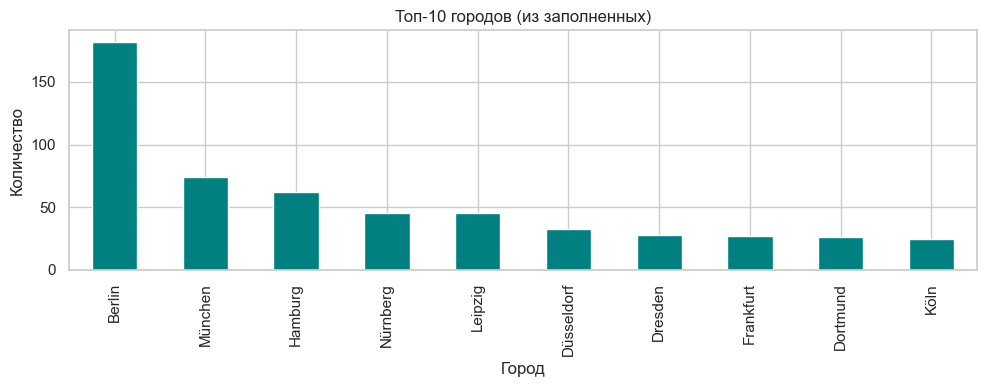

In [51]:
# City: топ-10 городов (из тех, где данные есть)
city_total = deals['City'].notna().sum()
city_pct = city_total / len(deals)
print(f'Заполнено: {city_total} из {len(deals)} ({city_pct:.1%})')
print(f'Пропущено: {deals["City"].isna().sum()} ({deals["City"].isna().mean():.1%})')
print()

city_counts = deals['City'].value_counts().head(10)
print('Топ-10 городов:')
print(city_counts)

fig, ax = plt.subplots(figsize=(10, 4))
city_counts.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Топ-10 городов (из заполненных)')
ax.set_xlabel('Город')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по City:**

Большинство лидов — из крупных городов (топ-5 концентрируют основной объём). Данные о городе помогут при географическом таргетинге маркетинга. Строки с "-" в названии города были очищены на этапе 1.

#### 2.1.3.12 Флаги аномалий (closing_date_error, amount_error, отсутствие Closing Date)

> Разобраны в `01_cleaning.ipynb`. Строк с `closing_date_error`: 44 (0.2%), с `amount_error`: 58 (0.27%) — менее 0.3% от всех сделок. Сделки сохранены, флаги используются как фильтр при расчётах. Дополнительная аномалия — финальные сделки без `Closing Date` — разобрана ниже.

In [52]:
# Сделки в финальном статусе (Payment Done / Lost) без даты закрытия
# В CRM изменение статуса на финальный должно автоматически фиксировать Closing Date.
# Отсутствие даты — аномалия, требующая объяснения.

final_no_date = deals[
    deals['Stage'].isin(['Payment Done', 'Lost']) & deals['Closing Date'].isna()
]

pd_no_date   = deals[(deals['Stage'] == 'Payment Done') & deals['Closing Date'].isna()]
lost_no_date = deals[(deals['Stage'] == 'Lost') & deals['Closing Date'].isna()]

print('Финальные сделки без даты закрытия:')
print(f'  Payment Done без Closing Date: {len(pd_no_date):>5}'
      f'  ({len(pd_no_date)/deals[deals["Stage"]=="Payment Done"].shape[0]*100:.1f}% от всех Payment Done)')
print(f'  Lost без Closing Date:         {len(lost_no_date):>5}'
      f'  ({len(lost_no_date)/deals[deals["Stage"]=="Lost"].shape[0]*100:.1f}% от всех Lost)')
print(f'  Итого:                         {len(final_no_date)}')


Финальные сделки без даты закрытия:
  Payment Done без Closing Date:   337  (39.3% от всех Payment Done)
  Lost без Closing Date:          1885  (12.0% от всех Lost)
  Итого:                         2222


> **Наблюдение:** в нормально настроенной CRM переход сделки в статус `Payment Done` или `Lost` должен **автоматически фиксировать** `Closing Date`. Наличие 337 оплаченных и 1 885 потерянных сделок без даты закрытия — аномалия данных. Возможные причины: ручная очистка поля, импорт без маппинга дат, нестандартная конфигурация CRM, либо намеренное усложнение датасета.

> Эти сделки **не исключаются из бизнес-анализа** (конверсия, суммы), но **исключаются из анализа времени жизни сделки** (раздел 4 в этапе 3) — без `Closing Date` длительность вычислить невозможно.

In [53]:
# Q9: сделки со статусом Payment Done и заполненным Lost Reason
# В норме Lost Reason заполняется только для статуса Lost.
# Наличие причины отказа у оплаченных сделок — аномалия CRM.
pd_with_reason = deals[
    (deals['Stage'] == 'Payment Done') & deals['Lost Reason'].notna()
]
pd_wr_paid = pd_with_reason[pd_with_reason['Initial Amount Paid'].notna()]

print(f'Payment Done + Lost Reason заполнен: {len(pd_with_reason)} сделок')
print(f'  Из них с суммой оплаты (учитываются в revenue): {len(pd_wr_paid)}')
print(f'  Без суммы оплаты:                               {len(pd_with_reason) - len(pd_wr_paid)}')
print()
print('Распределение по причинам:')
print(pd_with_reason['Lost Reason'].value_counts().to_string())

Payment Done + Lost Reason заполнен: 115 сделок
  Из них с суммой оплаты (учитываются в revenue): 101
  Без суммы оплаты:                               14

Распределение по причинам:
Lost Reason
Next stream                                40
Stopped Answering                          15
needs time to think                        15
Doesn't Answer                             15
Changed Decision                            7
Expensive                                   6
Non target                                  4
Conditions are not suitable                 4
Invalid number                              3
Gutstein refusal                            3
Duplicate                                   2
Does not know how to use a computer         1
Considering a different direction in IT     0
Didn't leave an application                 0
Does not speak English                      0
Inadequate                                  0
Not for myself                              0
Refugee                

> **Аномалия CRM: Payment Done + Lost Reason.** У 115 оплаченных сделок заполнено поле `Lost Reason`, которое должно заполняться только для потерянных сделок. Наиболее вероятная причина: менеджер заполнял причину отказа в процессе переговоров («Next stream» — 40 сделок, «Doesn't Answer» — 15), после чего клиент всё же оплатил, но поле не было очищено. 101 из этих сделок имеет сумму оплаты и **включаются в расчёты revenue** — поле `Lost Reason` не влияет на наше определение оплаты (фильтр: Stage + сумма).

### 2.1.4 Двумерный анализ числовых (pairplot)

Парный график показывает линейную зависимость между всеми парами числовых переменных.

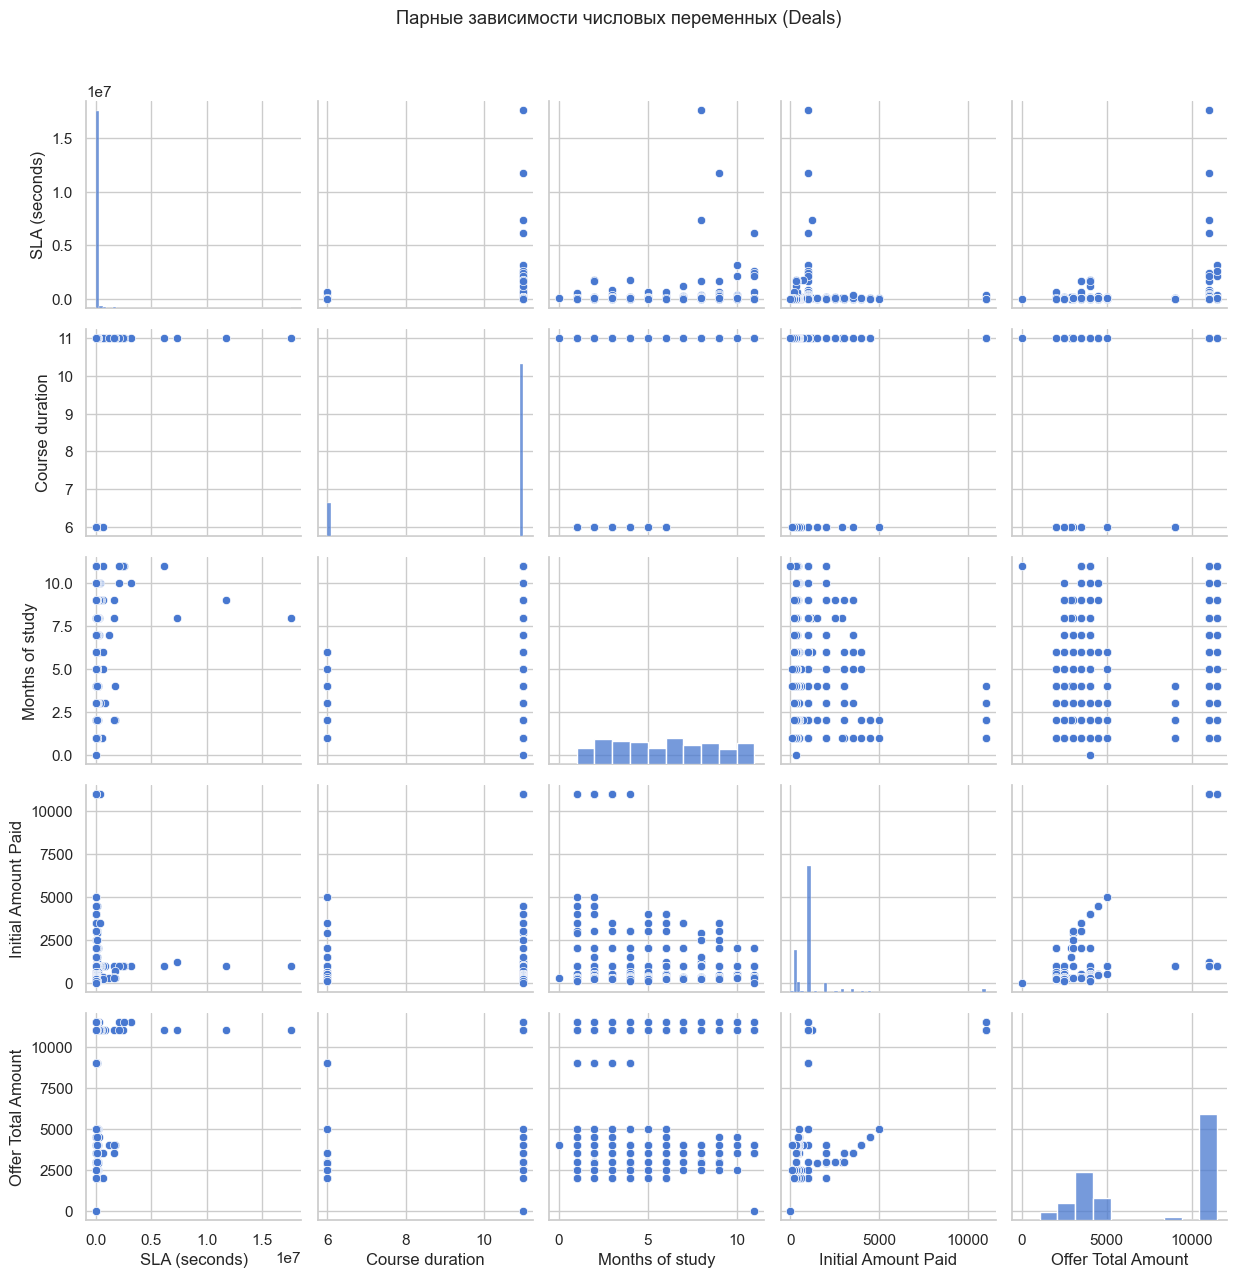

In [54]:
# Парный график (pairplot) для числовых полей Deals
# Каждая ячейка — scatter plot двух переменных, диагональ — распределение
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

sns.pairplot(deals[num_deals].dropna())
plt.suptitle('Парные зависимости числовых переменных (Deals)', y=1.02)
plt.tight_layout()
plt.show()

In [55]:
# Корреляционная матрица — точные коэффициенты для выводов
num_deals = ['SLA (seconds)', 'Course duration', 'Months of study',
             'Initial Amount Paid', 'Offer Total Amount']

corr_matrix = deals[num_deals].corr().round(2)
print('Корреляционная матрица (Pearson):')
print(corr_matrix)

Корреляционная матрица (Pearson):
                     SLA (seconds)  Course duration  Months of study  \
SLA (seconds)                 1.00             0.00             0.10   
Course duration               0.00             1.00             0.27   
Months of study               0.10             0.27             1.00   
Initial Amount Paid           0.00             0.03            -0.17   
Offer Total Amount            0.06             0.48             0.07   

                     Initial Amount Paid  Offer Total Amount  
SLA (seconds)                       0.00                0.06  
Course duration                     0.03                0.48  
Months of study                    -0.17                0.07  
Initial Amount Paid                 1.00                0.33  
Offer Total Amount                  0.33                1.00  


### 2.1.5 Многомерный анализ (heatmap)

Тепловая карта — визуальное представление корреляционной матрицы из раздела 2.1.4. Цвет заменяет число: тёмно-красный = сильная прямая связь, тёмно-синий = обратная, белый = нет связи.

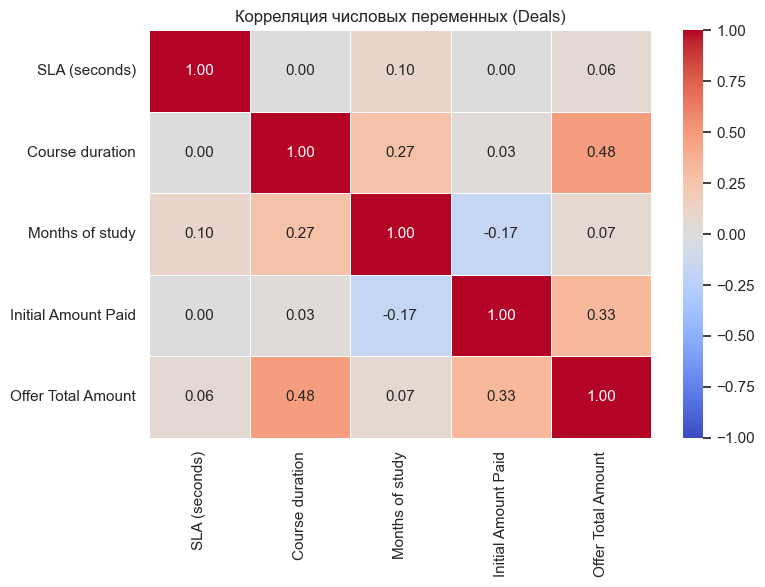

In [56]:
# Тепловая карта — визуализация corr_matrix из раздела 2.1.4
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Корреляция числовых переменных (Deals)')
plt.tight_layout()
plt.show()

**Вывод по 2.1.4–2.1.5 (pairplot + heatmap):**

Парный график и тепловая карта показывают одно и то же с разных сторон.

| Пара переменных | r | Интерпретация |
|---|---|---|
| Course duration ↔ Offer Total Amount | **0.48** | Умеренная — длиннее курс, выше цена |
| Course duration ↔ Months of study | **0.27** | Слабая — более длинные курсы дольше учатся |
| Initial Amount Paid ↔ Offer Total Amount | **0.29** | Слабая — первый платёж отражает стоимость |
| SLA ↔ всё остальное | **≈ 0.00–0.10** | Нет связи — скорость обработки лида не зависит от продукта |

**Главный вывод:** единственная значимая зависимость — `Course duration` и `Offer Total Amount` (r = 0.48). Остальные переменные практически независимы друг от друга.

## 2.2 Таблица Calls

### 2.2.1 Call Type (категориальный)

In [57]:
call_type_counts = calls['Call Type'].value_counts()
print(call_type_counts)
print()
print(f'Доля исходящих (Outbound): {call_type_counts.get("Outbound", 0) / len(calls):.1%}')


Call Type
Outbound    86875
Missed       5921
Inbound      3078
Name: count, dtype: int64

Доля исходящих (Outbound): 90.6%


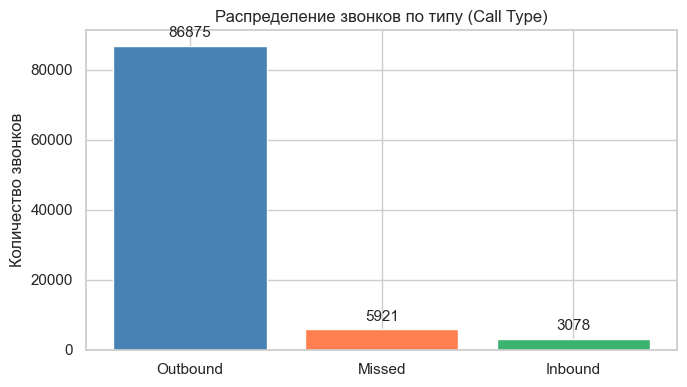

In [58]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(call_type_counts.index, call_type_counts.values, color=colors)
ax.set_title('Распределение звонков по типу (Call Type)')
ax.set_ylabel('Количество звонков')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_type.png', dpi=100)
plt.show()


**Вывод по Call Type:**

Исходящие звонки (Outgoing) преобладают — менеджеры сами инициируют контакт с лидами. Входящие (Incoming) — менее частые тёплые обращения. Связать направление звонка с исходом конкретной сделки нельзя: звонки не атрибутированы к сделке, поэтому ограничиваемся описательной картиной.

### 2.2.2 Call Duration (числовой)

In [59]:
# Call Duration в секундах — конвертируем в минуты
# Смотрим только на исходящие завершённые звонки (Outbound)
duration_sec = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Call Duration (in seconds)'].notna(),
    'Call Duration (in seconds)'
]
duration_min = duration_sec / 60

print(f'Исходящих звонков с длительностью: {len(duration_min)}')
print(f'Среднее:  {duration_min.mean():.1f} мин')
print(f'Медиана:  {duration_min.median():.1f} мин')
print(f'Q1:       {duration_min.quantile(0.25):.1f} мин')
print(f'Q3:       {duration_min.quantile(0.75):.1f} мин')
print(f'Макс:     {duration_min.max():.1f} мин')


Исходящих звонков с длительностью: 86792
Среднее:  2.8 мин
Медиана:  0.1 мин
Q1:       0.1 мин
Q3:       1.7 мин
Макс:     127.1 мин


In [60]:
# Ограничиваем до 30 минут — крайние выбросы искажают картину
duration_trimmed = duration_min[duration_min <= 30]
print(f'Звонков ≤ 30 мин: {len(duration_trimmed)} '
      f'({len(duration_trimmed)/len(duration_min):.1%} от всех)')


Звонков ≤ 30 мин: 85458 (98.5% от всех)


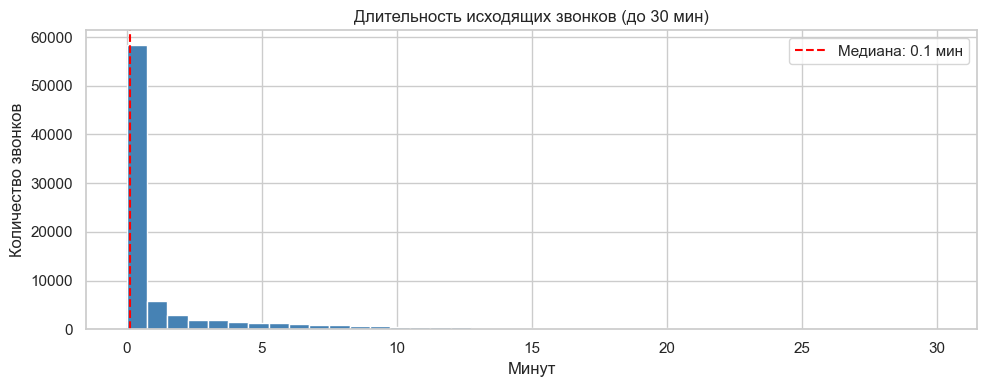

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(duration_trimmed, bins=40, color='steelblue', edgecolor='white')
ax.set_title('Длительность исходящих звонков (до 30 мин)')
ax.set_xlabel('Минут')
ax.set_ylabel('Количество звонков')
ax.axvline(duration_trimmed.median(), color='red', linestyle='--',
           label=f'Медиана: {duration_trimmed.median():.1f} мин')
ax.legend()

plt.tight_layout()
plt.savefig('../data_clean/plots/call_duration.png', dpi=100)
plt.show()


**Вывод по Call Duration:**

Большинство звонков — короткие (до 5 минут). Медиана значительно ниже среднего из-за выбросов: очень длинные звонки — консультации или технические проблемы (зависшие записи). Длительность звонка — косвенный индикатор вовлечённости лида.

In [62]:
# Доля очень коротких звонков — вероятно, недозвоны
short_calls = (duration_min <= 0.5).sum()  # ≤ 30 секунд
print(f'Звонков ≤ 30 сек (вероятно, недозвоны): '
      f'{short_calls} ({short_calls/len(duration_min):.1%})')
print()
print('Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.')
print('Это означает, что часть исходящих — недозвоны или отказы с порога.')


Звонков ≤ 30 сек (вероятно, недозвоны): 55382 (63.8%)

Вывод: типичный разговор ~4-5 мин; значительная доля звонков очень короткие.
Это означает, что часть исходящих — недозвоны или отказы с порога.


### 2.2.3 Outgoing Call Status

In [63]:
# Outgoing Call Status — заполнен только для исходящих звонков
outbound_status = calls.loc[
    calls['Call Type'] == 'Outbound',
    'Outgoing Call Status'
].value_counts(dropna=False)

print('Статус исходящих звонков:')
print(outbound_status)


Статус исходящих звонков:
Outgoing Call Status
Completed    86792
Overdue         60
Cancelled       20
Scheduled        3
Name: count, dtype: int64


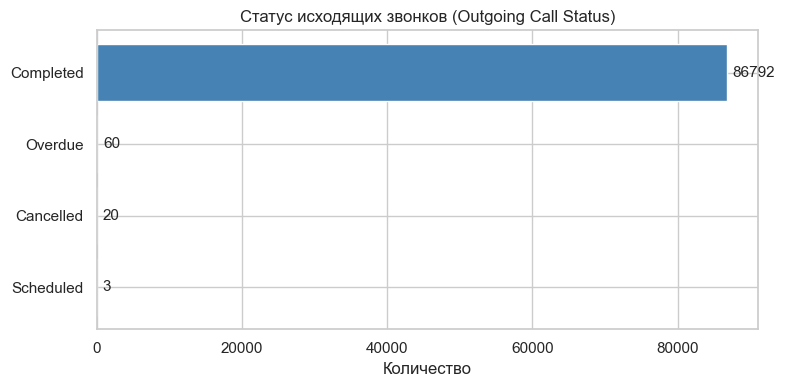

In [64]:
status_known = calls.loc[
    (calls['Call Type'] == 'Outbound') & calls['Outgoing Call Status'].notna(),
    'Outgoing Call Status'
].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(status_known.index[::-1], status_known.values[::-1],
               color='steelblue')
ax.set_title('Статус исходящих звонков (Outgoing Call Status)')
ax.set_xlabel('Количество')
ax.bar_label(bars, fmt='%d', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/call_status.png', dpi=100)
plt.show()


**Вывод по Outgoing Call Status:**

99.9% всех заполненных исходящих звонков имеют статус `Completed`. Поле практически неинформативно для анализа — все звонки фиксируются как завершённые. 9.4% строк — пропуски (входящие звонки, у которых нет исходящего статуса). Реальное качество дозвона лучше отслеживать через `Call Status`.

### 2.2.4 Call Status

Общий результат звонка — включая входящие и исходящие.

                            Количество  Доля, %
Call Status                                    
Attended Dialled                 70703     73.7
Unattended Dialled               16030     16.7
Missed                            5922      6.2
Received                          3077      3.2
Overdue                             60      0.1
Scheduled Attended Delay            22      0.0
Cancelled                           20      0.0
Scheduled Unattended Delay          17      0.0
Scheduled Attended                  14      0.0
Scheduled Unattended                 6      0.0
Scheduled                            3      0.0


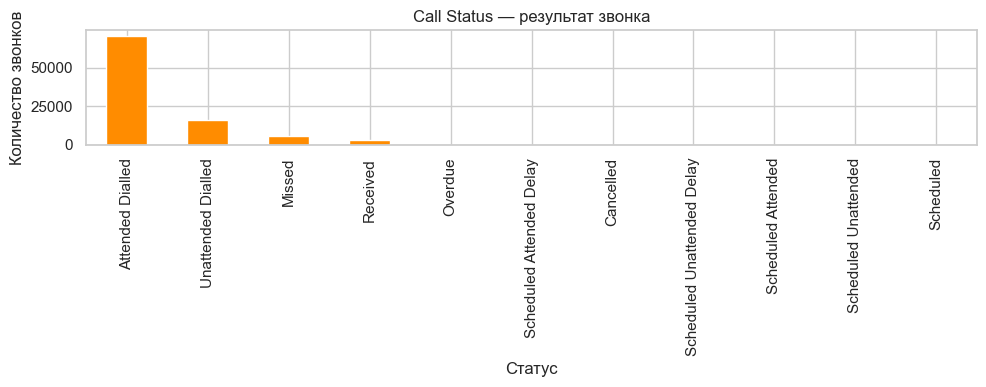

In [65]:
# Call Status — результат звонка для всех типов
status_df = pd.DataFrame({
    'Количество': calls['Call Status'].value_counts(),
    'Доля, %': (calls['Call Status'].value_counts(normalize=True) * 100).round(1)
})
print(status_df)

fig, ax = plt.subplots(figsize=(10, 4))
status_df['Количество'].plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Call Status — результат звонка')
ax.set_xlabel('Статус')
ax.set_ylabel('Количество звонков')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по Call Status:**

73.7% звонков — `Attended Dialled` (исходящий, клиент ответил). 16.7% — `Unattended Dialled` (не дозвонились). 6.2% — `Missed` (входящий пропущен). 3.2% — `Received` (входящий принят).

**Ключевой вывод:** каждый 6-й исходящий звонок остаётся без ответа. В сочетании с `Doesn't Answer` как главной причиной потери сделок — это системная проблема с дозвоном, а не разовые ситуации.

### 2.2.5 Call Owner Name

Распределение звонков по сотрудникам.

In [66]:
# Сначала смотрим сколько всего менеджеров в звонках
total_call_owners = calls['Call Owner Name'].nunique()
print(f'Всего менеджеров в звонках: {total_call_owners}')
print(f'Показываем топ-15 по количеству звонков')

Всего менеджеров в звонках: 33
Показываем топ-15 по количеству звонков


Call Owner Name
Yara Edwards       9059
Julia Nelson       7446
Ian Miller         7215
Charlie Davis      7213
Diana Evans        6857
Ulysses Adams      6085
Amy Green          5982
Nina Scott         5581
Victor Barnes      5439
Kevin Parker       5406
Paula Underwood    4580
Quincy Vincent     4384
Jane Smith         3753
Cara Iverson       3300
John Doe           2986
Name: count, dtype: int64


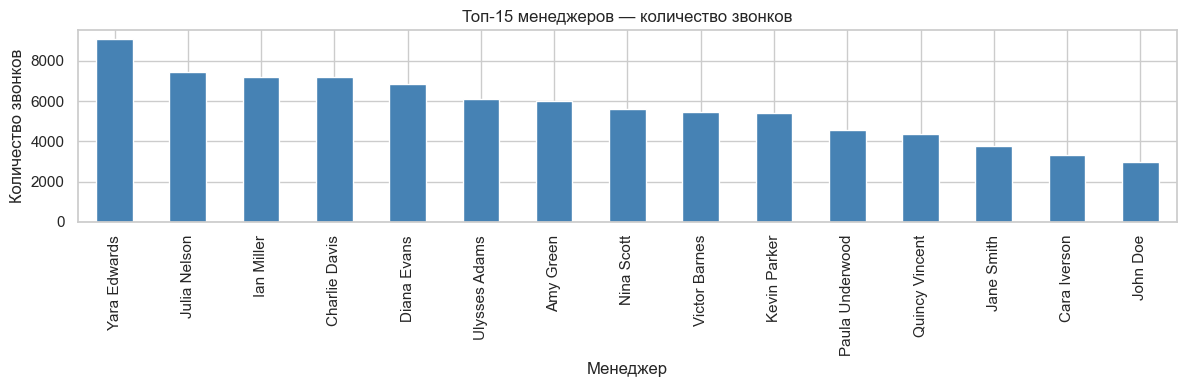

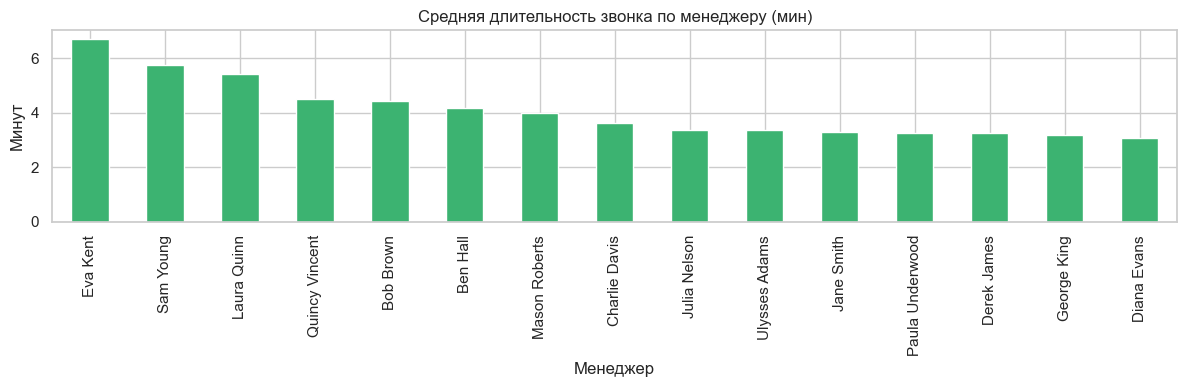

In [67]:
# Топ-15 менеджеров по количеству звонков
call_owner = calls['Call Owner Name'].value_counts().head(15)
print(call_owner)

fig, ax = plt.subplots(figsize=(12, 4))
call_owner.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Топ-15 менеджеров — количество звонков')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Количество звонков')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# Средняя длительность звонка по менеджеру (двумерный: категория × число)
avg_dur = (
    calls.groupby('Call Owner Name', observed=True)['Call Duration (in seconds)']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    / 60  # в минуты
)
fig, ax = plt.subplots(figsize=(12, 4))
avg_dur.plot(kind='bar', ax=ax, color='mediumseagreen')
ax.set_title('Средняя длительность звонка по менеджеру (мин)')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Минут')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по Call Owner Name:**

Нагрузка по звонкам неравномерна между менеджерами. Прямое сопоставление объёма звонков с конверсией сделок ограничено: владелец звонка (Call Owner) и владелец сделки (Deal Owner) не всегда совпадают. Конверсию по менеджерам сделок разбираем в этапе 3 (раздел 7).

### 2.2.6 Scheduled in CRM

Показывает, был ли звонок запланирован заранее (1) или нет (0).

In [68]:
# Scheduled in CRM: 0 = не запланирован, 1 = запланирован
sched = calls['Scheduled in CRM'].value_counts(dropna=False)
print(sched)
scheduled_pct = (calls['Scheduled in CRM'] == 1).sum() / len(calls)
print(f'\nДоля запланированных: {scheduled_pct:.1%}')

Scheduled in CRM
0.0    86733
NaN     8999
1.0      142
Name: count, dtype: int64

Доля запланированных: 0.1%


**Вывод по Scheduled in CRM:**

Только 142 звонка из 95 874 (0.1%) были запланированы заранее. Фактически все звонки — спонтанные исходящие. Поле несёт минимальную аналитическую ценность в текущем состоянии данных.

## 2.3 Таблица Spend

### 2.3.1 Числовые переменные (Spend, Clicks, Impressions)

Spend — данные о расходах, кликах и показах по каналам.
Анализируем распределение расходов и эффективность по источникам.


In [69]:
# Числовая статистика по Spend
spend_nums = ['Spend', 'Clicks', 'Impressions']
print(spend[spend_nums].describe().round(2))


          Spend    Clicks  Impressions
count  19862.00  19862.00     19862.00
mean       7.53     25.10      2571.70
std       27.33     87.03     11691.23
min        0.00      0.00         0.00
25%        0.00      0.00         1.00
50%        0.74      2.00        82.00
75%        6.16     13.00       760.75
max      774.00   2415.00    431445.00


In [70]:
# Итоговые суммы за весь период
print('Итого за период (июль 2023 – июнь 2024):')
print(f'  Расходы (Spend):      {spend["Spend"].sum():,.0f} €')
print(f'  Клики (Clicks):       {spend["Clicks"].sum():,.0f}')
print(f'  Показы (Impressions): {spend["Impressions"].sum():,.0f}')


Итого за период (июль 2023 – июнь 2024):
  Расходы (Spend):      149,523 €
  Клики (Clicks):       498,455
  Показы (Impressions): 51,079,010


**Вывод по числовым переменным Spend:**

За период июль 2023 – июнь 2024:
- Суммарные расходы: **149 523 €**, клики: **498 455**, показы: **51 079 010**
- Медианный дневной расход: **0.74 €** — большинство строк это мелкие ежедневные списания
- Максимум за день: **774 €** — пики активных кампаний
- Среднее (7.53 €) сильно выше медианы (0.74 €) — распределение правосторонне скошено, бюджет сконцентрирован в редких пиковых днях

### 2.3.2 Source (категориальный)

In [71]:
# Расходы по каналам — агрегируем по Source
spend_by_source = (
    spend.groupby('Source', observed=True)['Spend']
    .sum()
    .sort_values(ascending=False)
)

print('Расходы по каналам (€):')
print(spend_by_source)


Расходы по каналам (€):
Source
Google Ads        57798.60
Facebook Ads      33754.72
Youtube Ads       14633.33
Bloggers          13439.00
Tiktok Ads        11985.67
SMM                7269.52
Telegram posts     6860.36
Webinar            2874.04
Test                608.21
Radio               300.00
Organic               0.00
Offline               0.00
CRM                   0.00
Partnership           0.00
Name: Spend, dtype: float64


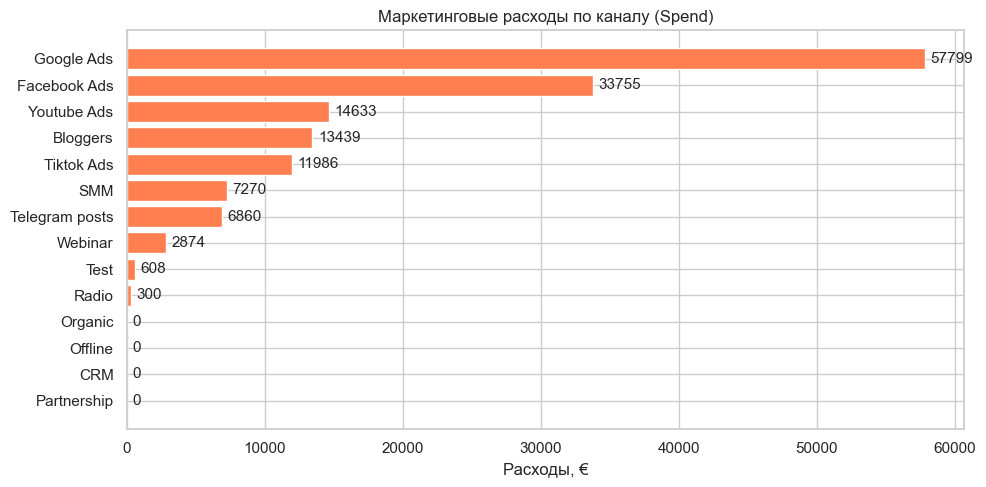

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(spend_by_source.index[::-1], spend_by_source.values[::-1],
               color='coral')
ax.set_title('Маркетинговые расходы по каналу (Spend)')
ax.set_xlabel('Расходы, €')
ax.bar_label(bars, fmt='%.0f', padding=4)

plt.tight_layout()
plt.savefig('../data_clean/plots/spend_by_source.png', dpi=100)
plt.show()


In [73]:
# CTR (Click-Through Rate) = Clicks / Impressions — эффективность объявлений
spend_summary = spend.groupby('Source', observed=True).agg(
    total_spend=('Spend', 'sum'),
    total_clicks=('Clicks', 'sum'),
    total_impressions=('Impressions', 'sum')
).reset_index()

spend_summary['CTR'] = ((
    spend_summary['total_clicks'] / spend_summary['total_impressions']
)*100).round(4)

spend_summary['CPC'] = (
    spend_summary['total_spend'] / spend_summary['total_clicks'].replace(0, np.nan)
).round(2)

print(spend_summary[['Source', 'total_spend', 'total_impressions', 'total_clicks',
                      'CTR', 'CPC']].sort_values('total_spend', ascending=False)
      .to_string(index=False))


        Source  total_spend  total_impressions  total_clicks     CTR  CPC
    Google Ads     57798.60           32752334        248487  0.7587 0.23
  Facebook Ads     33754.72            2850200         48133  1.6888 0.70
   Youtube Ads     14633.33            8655978         59061  0.6823 0.25
      Bloggers     13439.00             738460         14250  1.9297 0.94
    Tiktok Ads     11985.67            5007212         28268  0.5645 0.42
           SMM      7269.52              23772         11521 48.4646 0.63
Telegram posts      6860.36             705415         16777  2.3783 0.41
       Webinar      2874.04             301670          3241  1.0744 0.89
          Test       608.21              43969          1226  2.7883 0.50
         Radio       300.00                  0             0     NaN  NaN
       Organic         0.00                  0         59089     inf 0.00
       Offline         0.00                  0            57     inf 0.00
           CRM         0.00           

**Вывод по Source (Spend):**

Google Ads — крупнейший канал по расходам: 57 799 € (38.6% бюджета). Facebook Ads на втором месте: 33 755 € (22.6%). Youtube Ads и Bloggers — 14 633 € и 13 439 € соответственно. TikTok Ads — 11 986 €.

**Важно:** Webinar при минимальных расходах (2 874 €) показывал высокую конверсию — это будет ключевым выводом в юнит-экономике (этап 4).

### 2.3.3 Campaign (категориальный)

Анализируем топ кампаний по расходам.

In [74]:
# Сначала смотрим сколько всего кампаний в Spend
total_camp_spend = spend['Campaign'].nunique()
print(f'Всего кампаний в Spend: {total_camp_spend}')
print(f'Показываем топ-15 по сумме расходов')

Всего кампаний в Spend: 51
Показываем топ-15 по сумме расходов


Топ-15 кампаний по расходам (€):
Campaign
performancemax_eng_DE        34183.45
youtube_shorts_DE            14149.22
discovery_DE                  9750.63
12.07.2023wide_DE             9471.52
02.07.23wide_DE               6913.60
04.07.23recentlymoved_DE      4523.31
03.07.23women                 4219.75
07.07.23LAL_DE                4200.37
12.09.23interests_Uxui_DE     3753.06
performancemax_wide_AT        3491.74
brand_search_eng_DE           3457.82
1performancemax_wide_PL       2961.38
24.09.23retargeting_DE        2817.29
gen_analyst_DE                2551.00
17.03.24wide_AT               1435.24
Name: Spend, dtype: float64


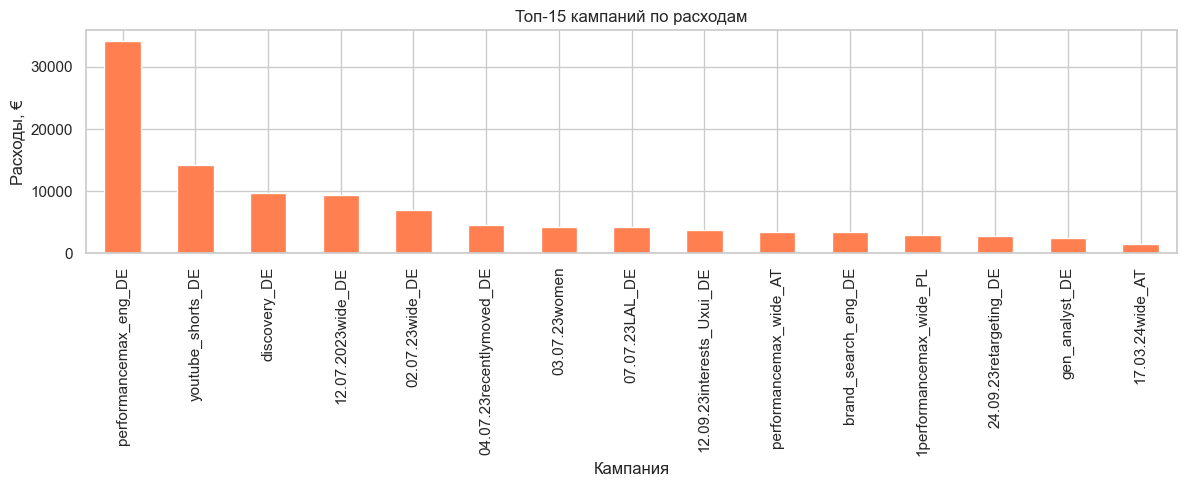

In [75]:
# Топ-15 кампаний по расходам
camp_spend = (
    spend.groupby('Campaign', observed=True)['Spend']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)
print('Топ-15 кампаний по расходам (€):')
print(camp_spend)

fig, ax = plt.subplots(figsize=(12, 5))
camp_spend.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Топ-15 кампаний по расходам')
ax.set_xlabel('Кампания')
ax.set_ylabel('Расходы, €')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по Campaign (Spend):**

Топ кампания — `performancemax_eng_DE`: 34 183 € (22.8% всего бюджета). На втором месте `youtube_shorts_DE`: 14 149 €. Расходы сильно сконцентрированы: топ-5 кампаний забирают более 50% бюджета.

## 2.4 Таблица Contacts

Contacts — справочная таблица с данными о контактах. Содержит: `Contact Owner Name` (менеджер), `Created Time` (дата создания).

In [76]:
# Базовая статистика по Contacts
print(f'Всего контактов: {len(contacts)}')
print(f'Столбцы: {list(contacts.columns)}')
print(f'Пропуски:')
print(contacts.isnull().sum())

Всего контактов: 18548
Столбцы: ['Id', 'Contact Owner Name', 'Created Time', 'Modified Time']
Пропуски:
Id                    0
Contact Owner Name    0
Created Time          0
Modified Time         0
dtype: int64


### 2.4.1 Contact Owner Name (категориальный)

In [77]:
# Сначала смотрим сколько всего менеджеров контактов
total_contact_owners = contacts['Contact Owner Name'].nunique()
print(f'Всего менеджеров контактов: {total_contact_owners}')
print(f'Показываем топ-15 по количеству контактов')

Всего менеджеров контактов: 28
Показываем топ-15 по количеству контактов


Contact Owner Name
Charlie Davis      2018
Ulysses Adams      1816
Julia Nelson       1769
Paula Underwood    1487
Quincy Vincent     1416
Nina Scott         1150
Ben Hall           1038
Victor Barnes       967
Cara Iverson        880
Rachel White        782
Jane Smith          754
Bob Brown           685
Ian Miller          684
Diana Evans         678
Yara Edwards        655
Name: count, dtype: int64


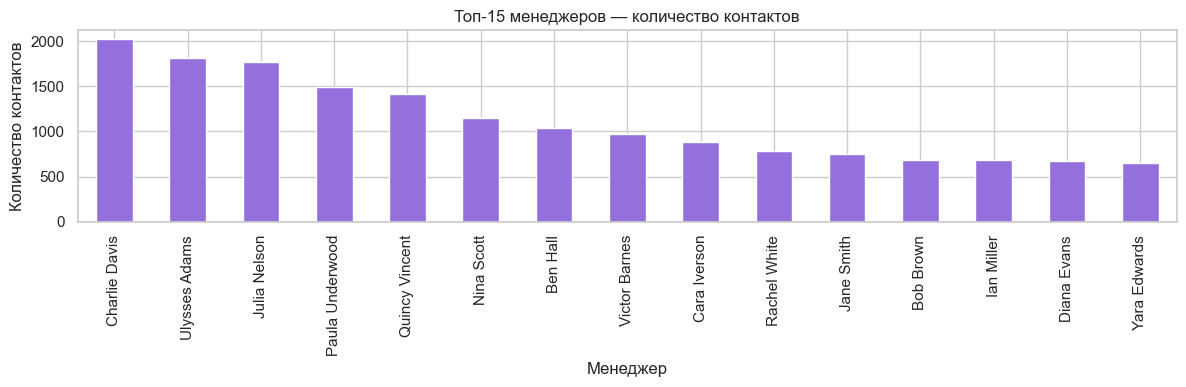

In [78]:
# Распределение контактов по менеджерам
contact_owner = contacts['Contact Owner Name'].value_counts().head(15)
print(contact_owner)

fig, ax = plt.subplots(figsize=(12, 4))
contact_owner.plot(kind='bar', ax=ax, color='mediumpurple')
ax.set_title('Топ-15 менеджеров — количество контактов')
ax.set_xlabel('Менеджер')
ax.set_ylabel('Количество контактов')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Вывод по Contact Owner Name:**

Всего 28 менеджеров. Лидирует Charlie Davis (2 018 контактов), далее Ulysses Adams (1 816) и Julia Nelson (1 769). Нагрузка распределена неравномерно — топ-3 менеджера ведут примерно в 3 раза больше контактов чем замыкающие список.

> Динамика создания сделок во времени — в этапе 3 (раздел 2).

### 2.4.2 Created Time (временной тренд)

Created Time
2023-06-30       1
2023-07-31     630
2023-08-31     899
2023-09-30     992
2023-10-31    1458
2023-11-30    1576
2023-12-31    1668
2024-01-31    1992
2024-02-29    1730
2024-03-31    2009
2024-04-30    2535
2024-05-31    1849
2024-06-30    1209
Freq: ME, dtype: int64


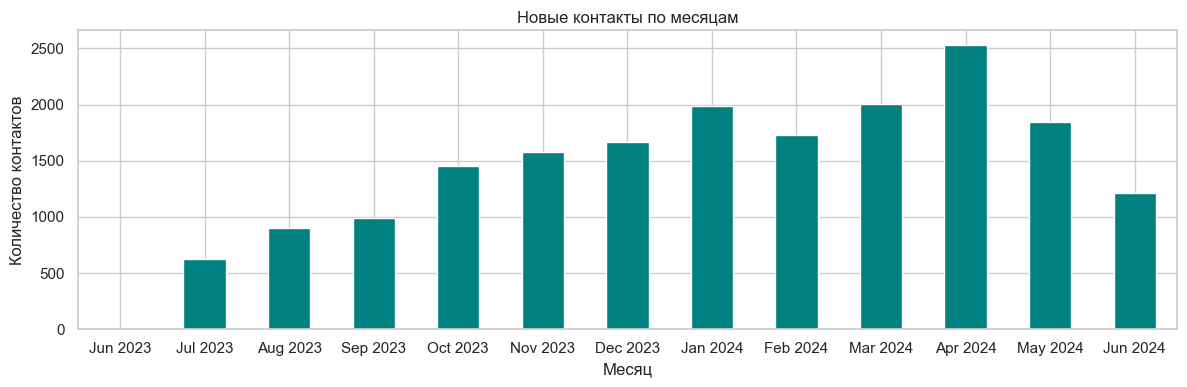

In [79]:
# Группируем по месяцу
contacts['Created Time'] = pd.to_datetime(contacts['Created Time'])
contacts_by_month = (
    contacts.set_index('Created Time')
    .resample('ME')
    .size()
)
print(contacts_by_month)

fig, ax = plt.subplots(figsize=(12, 4))
contacts_by_month.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Новые контакты по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество контактов')
ax.set_xticklabels([d.strftime('%b %Y') for d in contacts_by_month.index], rotation=0)
plt.tight_layout()
plt.show()

**Вывод по Created Time (Contacts):**

Данные охватывают один год: июнь 2023 – июнь 2024. За этот период виден рост: с ~650 контактов в июле 2023 до пика ~2 500 в апреле 2024. С октября 2023 объём стабилизировался на уровне 1 500–2 000 контактов в месяц.

> Одного года недостаточно чтобы говорить о сезонности — для этого нужно минимум два года чтобы сравнить одинаковые месяцы между собой. Здесь мы видим только тренд внутри одного периода.

## 3. Сводные выводы

In [80]:
print('=== Ключевые выводы этапа 2 ===')
print()
print('ВОРОНКА ПРОДАЖ:')
print(f'  Всего сделок: {len(deals):,}')
payment_n = (deals["Stage"] == "Payment Done").sum()
lost_n = (deals["Stage"] == "Lost").sum()
print(f'  Оплачено: {payment_n} ({payment_n/len(deals):.1%})')
print(f'  Потеряно: {lost_n} ({lost_n/len(deals):.1%})')
print()
print('ФИНАНСЫ (без символических оплат 0/1/9 €):')
iap_clean = deals.loc[(~deals["Initial Amount Paid"].isin([0, 1, 9])) & deals["Initial Amount Paid"].notna(),
                      "Initial Amount Paid"]
print(f'  Медиана первого платежа: {iap_clean.median():.0f} €')
print()
print('КАЧЕСТВО ЛИДОВ:')
low_quality = deals['Quality'].isin(['D - Non Target', 'E - Non Qualified']).sum()
print(f'  D+E (нецелевые): {low_quality} ({low_quality/deals["Quality"].notna().sum():.1%})')
print()
total_spend = spend['Spend'].sum()
print(f'МАРКЕТИНГ: суммарный бюджет {total_spend:,.0f} €, '
      f'{spend["Clicks"].sum():,} кликов')


=== Ключевые выводы этапа 2 ===

ВОРОНКА ПРОДАЖ:
  Всего сделок: 21,593
  Оплачено: 858 (4.0%)
  Потеряно: 15743 (72.9%)

ФИНАНСЫ (без символических оплат 0/1/9 €):
  Медиана первого платежа: 1000 €

КАЧЕСТВО ЛИДОВ:
  D+E (нецелевые): 13882 (71.8%)

МАРКЕТИНГ: суммарный бюджет 149,523 €, 498,455 кликов


### Итоговая таблица этапа 2

| Показатель | Значение |
|---|---|
| Сделок всего | 21 593 |
| Конверсия в оплату | 858 (4.0%) |
| Потерянных сделок | 15 743 (72.9%) |
| Медиана первого платежа | 1 000 € |
| Доля нецелевых лидов (D+E) | 13 882 (71.8%) |
| SLA медиана | 5.5 ч |
| SLA максимум | 7 474 ч (311 дней) |
| Звонков всего | 95 874 |
| Доля исходящих | 86 875 (90.6%) |
| Доля недозвонов | 16 030 (16.7%) |
| Маркетинговый бюджет | 149 523 € |

**Главные инсайты:**
1. Конверсия 4% — низкая. 71.8% лидов нецелевые (D+E) — маркетинг гонит объём, а не качество.
2. Webinar — самый эффективный источник: конверсия 6.86% при минимальных расходах (2 874 €). Google Ads тратит 57 799 € при конверсии ниже.
3. Главная причина потери сделок — `Doesn't Answer` (4 074 случая). 16.7% исходящих звонков остаются без ответа. Это системная проблема дозвона, а не единичные ситуации.
4. SLA медиана 5.5 ч — половина лидов ждут первого контакта больше рабочей смены. Максимум — 311 дней.
5. Более 50% всех первых платежей — ровно 1 000 € (IQR = 0). Рассрочка — доминирующая модель оплаты.
6. Google Ads — крупнейший канал по расходам (57 799 €, 38.6% бюджета). Детальный CAC по каналам — в юнит-экономике (этап 4).

---
*Следующий этап: `03_analysis.ipynb` — временные ряды, кампании, отдел продаж, продукты, география.*